<a href="https://colab.research.google.com/github/mbenedicto99/SaturnProject/blob/main/fase1_dataset_saturno_v11_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset v1 — Imagens amadoras de Saturno para melhoria visual com IA
### Versão 9 — critério de validação de conteúdo versionado, split real balanceado confirmado em execução real

Este notebook monta a base de dados amadora de Saturno descrita no relatório de auditoria técnica do projeto, preparado para servir de base metodológica de uma dissertação. A versão 5 corrigiu o desbalanceamento do split real por observador e o vazamento de imagens de origem entre splits sintéticos; uma execução completa confirmou os dois: o split real saiu em 350/75/75, exatamente 70/15/15 de 500 imagens.

Essa mesma execução revelou um terceiro problema, mais sutil: a taxa de confirmação de conteúdo (componente V) caiu de forma abrupta e sem explicação aparente entre duas rodadas do notebook, para um catálogo praticamente idêntico. A causa era a lógica de reaproveitamento da seção 13.1, que só verificava se uma imagem já tinha alguma linha de classificação salva, sem checar sob qual critério essa linha foi gerada — uma confirmação feita sob um padrão antigo e mais permissivo (de uma versão anterior deste notebook) continuava valendo indefinidamente, mesmo depois do critério ficar bem mais rigoroso. Esta versão introduz `CONTENT_VALIDATION_VERSION`: cada classificação passa a registrar sob qual critério foi feita, e só conta como válida se corresponder à versão vigente, o que força a reclassificação completa sempre que o critério mudar.

### Versão 10 (esta versão) — recalibração dos limiares de validação de conteúdo

A execução completa da versão 6 revelou que os limiares de confiança (0.65) e margem (0.15) da validação CLIP, herdados sem mudança desde a v2, confirmavam só 4 das 500 imagens do catálogo (0,8%), com 107 na fila de revisão e 389 reprovadas. A distribuição de confiança por status daquela execução mostrou o classificador discriminando bem entre categorias, mas numa escala de confiança absoluta que este domínio de imagens amadoras simplesmente não alcança -- o limiar não estava filtrando por qualidade real da imagem, estava filtrando por uma expectativa de confiança calibrada para outro tipo de imagem. Esta versão recalibra `SATURN_CONFIDENCE_THRESHOLD`, `SATURN_MARGIN_THRESHOLD` e `BORDERLINE_CONFIDENCE_THRESHOLD` (seção 2) para valores compatíveis com a distribuição observada, mantendo a mesma lógica de três categorias e a mesma exceção para anéis quase de perfil, e passa a exportar um manifesto explícito de aprovação (`approved_for_training.csv`, seção 13.2) para a Fase 2 consumir diretamente, em vez de reclassificar tudo de novo com critérios que podiam divergir entre os dois notebooks.

---
**Ajuste posterior a esta execução (seção 13.4):** `gerar_manifesto_final()` deixou de
resolver imagens `borderline` sem revisão manual como `rejected` por omissão. Elas agora
entram no treino como `confirmed_pending_review`, com uma nova coluna `quality_tier`
(`high`/`low`) que distingue conteúdo confirmado (por classificador com alta confiança, ou
por revisão manual) de conteúdo aprovado com critério mais permissivo, ainda sem revisão
humana. Ver célula 13.4 e a nota de mudança nela.

## 1. Instalação de dependências

Esta célula instala as bibliotecas usadas ao longo do notebook: `pyvo` para consultar o serviço TAP do PVOL, `beautifulsoup4` para extrair links de páginas HTML (ALPO-Japan e BAA), `pillow` para abrir, validar e normalizar imagens, `pandas` para manifestos e catálogos em CSV, `tqdm` para barras de progresso, `scikit-image` e `astropy` como apoio a processamento de imagem e conversão de datas astronômicas, `requests` para as chamadas HTTP, e `transformers`/`torch` para a classificação automática de conteúdo via Hugging Face usada na seção 13.1.

No Colab, `torch` já costuma vir pré-instalado; a instalação aqui garante a versão e evita falha caso o notebook seja rodado em outro ambiente.

In [1]:
!pip -q install pyvo beautifulsoup4 pillow pandas tqdm scikit-image astropy requests transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.3 MB/s eta 0:00:00


## 1.1 Verificação do ambiente de execução (reprodutibilidade)

Para uma dissertação, a seção de metodologia normalmente exige que o ambiente computacional usado seja descrito com precisão suficiente para permitir nova execução. Esta célula registra a versão do Python, o sistema operacional, a data e hora de execução em UTC e a versão de cada biblioteca relevante, salvando tudo em `environment_report.json` dentro de `metadata/`. Esse arquivo pode ser citado diretamente no capítulo de metodologia ou anexado como apêndice, e evita a situação comum em que o texto da dissertação descreve um ambiente que já não corresponde ao que foi de fato executado.

In [2]:
import platform
import sys
import json
from datetime import datetime, timezone

RANDOM_SEED = 42

def build_environment_report():
    report = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": sys.version,
        "platform": platform.platform(),
        "random_seed": globals().get("RANDOM_SEED", "NÃO DEFINIDO (definir na Seção 2)"),
    }
    packages_to_check = [
        "pandas", "numpy", "PIL", "bs4", "requests", "tqdm",
        "pyvo", "astropy", "skimage",
    ]
    versions = {}
    for pkg_name in packages_to_check:
        try:
            module = __import__(pkg_name)
            versions[pkg_name] = getattr(module, "__version__", "versão não exposta pelo pacote")
        except Exception:
            versions[pkg_name] = "não instalado / não importável"
    report["package_versions"] = versions
    return report

# Esta célula depende de DIRS, que só existe após a montagem do Drive
# (seção 3). Por isso o relatório de ambiente só é salvo mais adiante,
# reaproveitando o dicionário construído aqui.
_environment_report = build_environment_report()
for k, v in _environment_report.items():
    print(f"{k}: {v}")

generated_at_utc: 2026-07-13T21:11:20.887584+00:00
python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.6.122+-x86_64-with-glibc2.35
random_seed: 42
package_versions: {'pandas': '2.2.2', 'numpy': '2.0.2', 'PIL': '11.3.0', 'bs4': '4.13.5', 'requests': '2.32.4', 'tqdm': '4.67.3', 'pyvo': '1.9.1', 'astropy': '7.2.1', 'skimage': '0.25.2'}


## 2. Imports e configuração geral

Aqui ficam os parâmetros que controlam toda a coleta: quantas imagens reais buscar (`INITIAL_IMAGE_COUNT`), o tamanho padrão de normalização (`IMAGE_SIZE`), quantos pares sintéticos gerar (`SYNTHETIC_PAIRS_COUNT`), quais fontes estão ativas e os limites de polidez de coleta (timeout, pausa entre downloads, número máximo de páginas HTML por fonte).

Duas adições em relação à versão original: um limite mínimo de lado para considerar uma imagem suspeita de ser ícone/logotipo (`ICON_SUSPECT_MAX_SIDE`), separado do limite mínimo absoluto (`MIN_IMAGE_SIDE`), e uma lista de termos que costumam aparecer em URLs de ícones, logos e elementos de interface (`ICON_URL_KEYWORDS`). Essa distinção nasceu de um achado da primeira execução: uma imagem de 100x100 pixels vinda da BAA foi aceita no catálogo porque passava do limite de 48 pixels, mas o tamanho quadrado e pequeno sugere fortemente um logotipo de página, não uma observação de Saturno.

In [3]:
import os
import re
import io
import csv
import json
import time
import math
import random
import hashlib
import shutil
import warnings
from pathlib import Path
from datetime import datetime, timezone
from urllib.parse import urljoin, urlparse

import requests
import pandas as pd
from bs4 import BeautifulSoup
from PIL import Image, ImageOps, ImageFilter, ImageEnhance
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

try:
    import pyvo
    HAS_PYVO = True
except Exception:
    HAS_PYVO = False

try:
    from astropy.time import Time as AstropyTime
    HAS_ASTROPY_TIME = True
except Exception:
    HAS_ASTROPY_TIME = False

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Quantidade inicial desejada de imagens reais baixadas.
# Elevado de 120 para 500 nesta versão: a prioridade desta fase passou a
# ser maximizar o volume de imagens disponíveis para análise de
# maturidade do dataset (score Q), em vez de travar a coleta em um
# número pequeno enquanto a revisão manual de licença não termina.
INITIAL_IMAGE_COUNT = 1000

# Tamanho padronizado para as imagens usadas no pipeline de treino.
IMAGE_SIZE = 256

# Número de pares sintéticos a gerar a partir das imagens normalizadas.
# Elevado de 300 para 1200 nesta versão: a Fase 2 mostrou que 300 pares
# davam poucos exemplos por faixa de degradação para o modelo aprender a
# cobrir bem os casos mais severos. Em vez de só aumentar o número e
# confiar no sorteio aleatório para cobrir a faixa toda de forma razoável,
# os pares agora são gerados por nível de severidade explícito (ver
# SEVERITY_TIERS abaixo), com uma cota igual por nível dentro de cada
# split — garantindo que degradações leves, moderadas, fortes e severas
# tenham representação equivalente no treino, na validação e no teste,
# em vez de depender de quantas vezes o sorteio aleatório calhou de
# aplicar cada combinação de parâmetros.
SYNTHETIC_PAIRS_COUNT = 1200

# Níveis de severidade de degradação sintética (novo nesta versão). Cada
# nível define faixas próprias para os mesmos cinco parâmetros já usados
# na v2/v3 (escala de reamostragem, raio de desfoque, sigma do ruído
# gaussiano, contraste e brilho) e uma faixa de qualidade JPEG. Quanto
# menor a escala de reamostragem e maior o sigma do ruído, mais severa a
# degradação. Diferente da versão anterior, o parâmetro sorteado para cada
# imagem passa a ser registrado no manifesto de pares sintéticos, em vez
# de um rótulo genérico igual para todos — isso é o que permite à Fase 2
# quebrar a avaliação por severidade real, e não por um substituto
# calculado a partir do erro entre entrada e referência.
SEVERITY_TIERS = {
    "leve": {
        "resize_scale_range": (0.65, 0.85),
        "blur_radius_range": (0.2, 0.6),
        "noise_sigma_range": (2, 6),
        "contrast_range": (0.85, 1.10),
        "brightness_range": (0.90, 1.10),
        "jpeg_quality_range": (65, 85),
    },
    "moderada": {
        "resize_scale_range": (0.55, 0.75),
        "blur_radius_range": (0.5, 1.0),
        "noise_sigma_range": (5, 10),
        "contrast_range": (0.75, 1.10),
        "brightness_range": (0.85, 1.10),
        "jpeg_quality_range": (50, 70),
    },
    "forte": {
        "resize_scale_range": (0.45, 0.65),
        "blur_radius_range": (0.9, 1.4),
        "noise_sigma_range": (9, 14),
        "contrast_range": (0.68, 1.10),
        "brightness_range": (0.80, 1.10),
        "jpeg_quality_range": (40, 55),
    },
    "severa": {
        "resize_scale_range": (0.35, 0.50),
        "blur_radius_range": (1.3, 1.8),
        "noise_sigma_range": (13, 18),
        "contrast_range": (0.60, 1.05),
        "brightness_range": (0.75, 1.05),
        "jpeg_quality_range": (30, 40),
    },
}

# Fontes ativadas.
USE_PVOL_TAP = True
USE_ALPO_JAPAN = True
USE_BAA = True
USE_MANUAL_MANIFEST = True

# Polidez de coleta.
REQUEST_TIMEOUT = 30
DOWNLOAD_SLEEP_SECONDS = 0.25
# Elevado de 12 para 40: com os URLs semente por apparition ano a ano
# (ver ALPO_JAPAN_SEED_URLS abaixo), o rastreador tem mais páginas
# reais para visitar, e um teto baixo cortava a coleta cedo demais.
MAX_HTML_PAGES_PER_SOURCE = 40
MIN_IMAGE_SIDE = 48
DOWNLOAD_MAX_RETRIES = 2

# Cota mínima por fonte ativa (nova nesta versão). Cada fonte ativa
# tenta contribuir com pelo menos essa fração da meta de download
# antes do restante da cota ser preenchido livremente por qualquer
# fonte. Existe para evitar a concentração quase total em uma única
# fonte observada na primeira execução (104 de 120 imagens vieram só
# do PVOL).
SOURCE_MIN_QUOTA_FRACTION = 0.10

# Nesta fase, a validação individual de licença deixou de ser um
# requisito para o score de maturidade Q (ver seção 14). O objetivo
# agora é reunir o máximo de imagens possível para a análise técnica;
# a checagem de licença/autoria permanece registrada em licenses.csv
# e continua obrigatória antes de qualquer publicação ou uso fora do
# ambiente de pesquisa, mas não bloqueia mais o andamento do pipeline.
REQUIRE_LICENSE_FOR_MATURITY = False

# Heurística anti ícone/logotipo (novo na v2).
# Imagens quadradas e pequenas vindas de fontes coletadas por HTML são
# tratadas como suspeitas, pois páginas institucionais costumam ter
# logotipos, ícones sociais e selos nesse formato.
ICON_SUSPECT_MAX_SIDE = 160
ICON_URL_KEYWORDS = ["logo", "icon", "favicon", "avatar", "banner", "sprite", "badge", "social", "button"]
SOURCES_TRUSTED_FOR_SMALL_IMAGES = {"pvol"}

USER_AGENT = (
    "Mozilla/5.0 (compatible; AcademicDatasetBuilder/1.0; "
    "Saturn amateur astronomy image dataset; educational research)"
)

HEADERS = {"User-Agent": USER_AGENT}

# Endpoints e páginas de origem.
PVOL_TAP_URL = "http://pvol2.ehu.eus:8083/tap"

ALPO_JAPAN_SEED_URLS = [
    "https://alpo-j.sakura.ne.jp/Latest/Saturn.htm",
]
# A página acima é só o índice, com um link por apparition anual.
# Nesta versão, os URLs de cada apparition (padrão confirmado:
# Saturn{ANO}Apparition.htm, ex.: Saturn2010Apparition.htm) entram
# diretamente como sementes, para que o rastreador não dependa de
# descobrir esses links sozinho dentro do orçamento de páginas.
ALPO_JAPAN_SEED_URLS += [
    f"https://alpo-j.sakura.ne.jp/Latest/Saturn{year}Apparition.htm"
    for year in range(2009, 2024)
]

BAA_SEED_URLS = [
    "https://britastro.org/section_information_/saturn-uranus-and-neptune-section-overview/apparition-galleries",
]

# Classificação automática de conteúdo via Hugging Face. Esta versão
# endurece bastante o critério em relação à v2/v3: a Fase 2 mostrou
# imagens sem anéis visíveis, ou com recorte parcial do disco, passando
# pelo filtro anterior porque o rótulo positivo só exigia "Saturno" de
# forma genérica. Agora o rótulo positivo exige disco e anéis visíveis ao
# mesmo tempo, com um limiar de confiança mais alto e uma margem mínima
# sobre a segunda opção mais provável.
#
# Um cuidado adicional entra aqui por causa de um fenômeno real do
# próprio Saturno: periodicamente (a última vez em 2025) o plano dos
# anéis cruza a linha de visada da Terra, e os anéis aparecem quase de
# perfil — uma linha fina ao longo do disco, não a elipse característica.
# Um critério rígido demais rejeitaria essas imagens legítimas junto com
# o lixo real (ícones, gráficos, recortes). Por isso a classificação
# passou a ter três resultados possíveis, não dois: confirmada (rótulo
# positivo com confiança e margem altas), fila de revisão (rótulo
# positivo ou rótulo de anéis quase de perfil, mas sem confiança/margem
# suficiente para confirmação automática) e reprovada (qualquer rótulo
# negativo vencendo com folga). Só as imagens confirmadas contam a favor
# do componente V do score de maturidade; as da fila de revisão ficam
# separadas em borderline_review_queue.csv, para que o pesquisador decida
# manualmente, em vez de o filtro decidir sozinho por elas.
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
SATURN_LABEL = "a clear photo of the planet Saturn showing both its disk and its rings"
EDGE_ON_RINGS_LABEL = "a photo of the planet Saturn with its rings seen nearly edge-on, appearing as a thin line across the disk"
NON_SATURN_LABELS = [
    "a photo of Saturn where the rings are not visible or too faint to see",
    "a close-up crop showing only part of a planet's disk with no rings visible",
    "a logo, icon, or website interface graphic",
    "a chart, graph, table, or diagram",
    "a photograph of a different planet or celestial object without rings",
    "a photograph unrelated to Saturn or astronomy",
]
SATURN_CONFIDENCE_THRESHOLD = 0.38
SATURN_MARGIN_THRESHOLD = 0.08
# Limiar mais baixo só para decidir o que entra na fila de revisão (em vez
# de ser reprovado direto): candidatos com o rótulo positivo ou o rótulo
# de anéis quase de perfil vencendo, mas com confiança abaixo do limiar
# rigoroso, caem aqui em vez de serem descartados sem chance de revisão.
BORDERLINE_CONFIDENCE_THRESHOLD = 0.35

# Recalibração desta versão (v9-ajustado): a execução v9 (limiares
# 0.45/0.08 de confirmação, 0.35 de fila) confirmou 120 das 1000 imagens,
# deixando 230 na fila de revisão manual (13.3). A auditoria dessa fila
# revelou dois problemas, não um só.
#
# Primeiro, um problema de lógica, não de limiar: a condição de
# confirmação exigia top["label"] == SATURN_LABEL, então nenhuma imagem
# com o rótulo de anéis quase de perfil (EDGE_ON_RINGS_LABEL) podia ser
# confirmada automaticamente, não importa o score ou a margem. Isso
# prendia na fila 70 das 230 imagens borderline, das quais 19 já
# satisfaziam os mesmos 0.45/0.08 exigidos do rótulo padrão (ex.: score
# 0.6006/margem 0.4116 e score 0.5767/margem 0.3711) — presas só por um
# detalhe estrutural do código, não por incerteza real do classificador.
# Essa correção está na seção 13.1 (uso de `top["label"] in
# positive_labels` em vez de `== SATURN_LABEL`).
#
# Segundo, a distribuição de confiança da execução v9 mostrou boa parte
# das 230 borderline com score entre 0.35 e 0.45 e margem já saudável —
# faixa consistente com fotos reais de Saturno que só não alcançaram o
# patamar de confiança absoluta que o CLIP raramente atinge neste
# domínio amador (mesmo padrão identificado na recalibração anterior).
# Descer SATURN_CONFIDENCE_THRESHOLD de 0.45 para 0.38, mantendo a
# margem em 0.08 e o piso da fila em 0.35, confirma automaticamente
# cerca de 129 das 230 imagens hoje em revisão (correção de rótulo +
# novo limiar combinadas), deixando a fila de revisão manual em torno de
# 100 imagens em vez de 228. Se a próxima rodada mostrar que a maioria
# das restantes também é Saturno válido, um novo ajuste pode descer mais
# um degrau, com a distribuição desta execução como referência — em vez
# de fazer os dois cortes de uma vez.

# Identificador do critério de classificação de conteúdo em uso. Uma
# execução real revelou que, sem isso, a seção 13.1 reaproveitava
# decisões antigas de execuções anteriores mesmo depois de SATURN_LABEL
# e os limiares terem mudado — como o filtro só verificava se a imagem já
# tinha ALGUMA linha em visual_validation.csv, uma imagem classificada
# como confirmada sob um critério antigo e mais permissivo continuava
# contando como confirmada indefinidamente, mesmo que o critério atual
# nunca tivesse sido aplicado a ela de fato. Mude esta string sempre que
# SATURN_LABEL, EDGE_ON_RINGS_LABEL, NON_SATURN_LABELS ou os limiares
# acima mudarem, para forçar a reclassificação de todo o catálogo sob o
# critério novo. Bump nesta versão por causa da correção do rótulo de
# anéis quase de perfil e da recalibração do limiar de confirmação.
CONTENT_VALIDATION_VERSION = "v4_edge_on_confirmavel_limiar_038"

# Caminho do Google Drive. Será definido após o mount.
DATASET_NAME = "dataset_saturno_v1"


## 3. Montar Google Drive e criar a estrutura de pastas

Esta célula monta o Google Drive da conta usada no Colab e cria toda a árvore de diretórios descrita no relatório de auditoria: `raw/` separado por fonte, `processed/normalized_256`, os três splits (`train`, `val`, `test`), os pares sintéticos organizados por partição e o diretório `metadata` onde ficam todos os manifestos CSV e o JSON de resumo. Essa separação é o que torna o dataset auditável — cada arquivo final pode ser rastreado até sua origem bruta.

Na primeira execução o Drive foi montado e a estrutura criada em `/content/drive/MyDrive/dataset_saturno_v1` sem incidentes.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = Path("/content/drive/MyDrive") / DATASET_NAME

DIRS = {
    "raw": DATASET_ROOT / "raw",
    "raw_pvol": DATASET_ROOT / "raw" / "pvol",
    "raw_alpo_japan": DATASET_ROOT / "raw" / "alpo_japan",
    "raw_baa": DATASET_ROOT / "raw" / "baa",
    "raw_manual": DATASET_ROOT / "raw" / "manual_manifest",
    "raw_manual_upload": DATASET_ROOT / "raw" / "manual_upload",
    "processed": DATASET_ROOT / "processed",
    "normalized": DATASET_ROOT / "processed" / "normalized_256",
    "splits": DATASET_ROOT / "splits",
    "train": DATASET_ROOT / "splits" / "train",
    "val": DATASET_ROOT / "splits" / "val",
    "test": DATASET_ROOT / "splits" / "test",
    "synthetic": DATASET_ROOT / "synthetic_pairs",
    "syn_train_degraded": DATASET_ROOT / "synthetic_pairs" / "train" / "degraded",
    "syn_train_target": DATASET_ROOT / "synthetic_pairs" / "train" / "target",
    "syn_val_degraded": DATASET_ROOT / "synthetic_pairs" / "val" / "degraded",
    "syn_val_target": DATASET_ROOT / "synthetic_pairs" / "val" / "target",
    "syn_test_degraded": DATASET_ROOT / "synthetic_pairs" / "test" / "degraded",
    "syn_test_target": DATASET_ROOT / "synthetic_pairs" / "test" / "target",
    "real_world_test": DATASET_ROOT / "real_world_test",
    "metadata": DATASET_ROOT / "metadata",
}

for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print(f"Dataset criado em: {DATASET_ROOT}")

env_report_path = DIRS["metadata"] / "environment_report.json"
with open(env_report_path, "w", encoding="utf-8") as f:
    json.dump(_environment_report, f, indent=2, ensure_ascii=False)
print(f"Relatório de ambiente salvo em: {env_report_path}")

Mounted at /content/drive
Dataset criado em: /content/drive/MyDrive/dataset_saturno_v1
Relatório de ambiente salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/environment_report.json


## 4. Funções utilitárias

Este bloco reúne as funções de apoio usadas pelo resto do notebook: geração de timestamps em UTC, cálculo de hash SHA-1 (para deduplicação e rastreabilidade), inferência de extensão de arquivo a partir da URL ou do cabeçalho HTTP, validação de que os bytes baixados são realmente uma imagem legível, e a função central `download_image`, que baixa, valida e registra cada candidato.

Duas mudanças em relação à v1. Primeiro, `is_probably_icon_or_logo` marca URLs que contenham termos típicos de elementos de interface, para que a etapa de coleta HTML já descarte esses links antes mesmo do download. Segundo, `download_image` ganhou uma verificação de dimensão suspeita: imagens pequenas e quadradas vindas de fontes coletadas por HTML (não confiáveis por padrão, como BAA e ALPO-Japan) são marcadas com o status `suspect_icon_dimensions` em vez de `ok`, para que não entrem no catálogo mestre sem revisão humana. Isso corrige o caso observado na primeira execução, em que uma imagem de 100x100 pixels da BAA foi aceita como se fosse uma observação de Saturno.

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp", ".tif", ".tiff"}

def utc_now_iso():
    return datetime.now(timezone.utc).isoformat()

def sha1_text(text: str) -> str:
    return hashlib.sha1(text.encode("utf-8", errors="ignore")).hexdigest()

def sha1_bytes(data: bytes) -> str:
    return hashlib.sha1(data).hexdigest()

def safe_suffix_from_url(url: str, content_type: str = "") -> str:
    path = urlparse(url).path
    suffix = Path(path).suffix.lower()
    if suffix in IMAGE_EXTENSIONS:
        return ".jpg" if suffix == ".jpeg" else suffix
    content_type = (content_type or "").lower()
    if "png" in content_type:
        return ".png"
    if "webp" in content_type:
        return ".webp"
    if "tiff" in content_type or "tif" in content_type:
        return ".tif"
    if "gif" in content_type:
        return ".gif"
    return ".jpg"

def is_probably_image_url(url: str) -> bool:
    parsed = urlparse(url)
    path = parsed.path.lower()
    if any(path.endswith(ext) for ext in IMAGE_EXTENSIONS):
        return True
    if "image" in path or "img" in path or "photo" in path:
        return True
    return False

def is_probably_icon_or_logo(url: str) -> bool:
    '''Heurística nova na v2: descarta links que parecem ícones, logos,
    avatares ou selos de página, comuns em coletas HTML institucionais.'''
    low = url.lower()
    return any(keyword in low for keyword in ICON_URL_KEYWORDS)

def image_info_from_bytes(data: bytes):
    with Image.open(io.BytesIO(data)) as img:
        img.verify()
    with Image.open(io.BytesIO(data)) as img:
        return img.size[0], img.size[1], img.mode, img.format

def download_image(url, out_dir: Path, source: str, extra_metadata=None):
    extra_metadata = extra_metadata or {}
    out_dir.mkdir(parents=True, exist_ok=True)
    record = {
        "source": source,
        "original_url": url,
        "downloaded_at_utc": utc_now_iso(),
        "status": "pending",
        "local_path": "",
        "sha1_file": "",
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
        "license_note": extra_metadata.get("license_note", "verificar licença/autoria antes de uso público"),
        "object": extra_metadata.get("object", "Saturn"),
        "observer": extra_metadata.get("observer", ""),
        "date_utc": extra_metadata.get("date_utc", ""),
        "telescope": extra_metadata.get("telescope", ""),
        "camera": extra_metadata.get("camera", ""),
        "filter": extra_metadata.get("filter", ""),
        "notes": extra_metadata.get("notes", ""),
    }

    resp = None
    last_exc = None
    for attempt in range(DOWNLOAD_MAX_RETRIES + 1):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=REQUEST_TIMEOUT, stream=True)
            break
        except Exception as exc:
            last_exc = exc
            resp = None
            time.sleep(0.5 * (attempt + 1))

    if resp is None:
        record["status"] = f"error: {type(last_exc).__name__ if last_exc else 'unknown'}: {last_exc}"
        return record

    try:
        record["http_status"] = resp.status_code
        if resp.status_code != 200:
            record["status"] = f"http_{resp.status_code}"
            return record

        content_type = resp.headers.get("Content-Type", "")
        data = resp.content

        if len(data) < 1024:
            record["status"] = "too_small"
            return record

        try:
            width, height, mode, fmt = image_info_from_bytes(data)
        except Exception as exc:
            record["status"] = f"invalid_image: {type(exc).__name__}"
            return record

        if min(width, height) < MIN_IMAGE_SIDE:
            record["status"] = "image_too_small"
            record["width"] = width
            record["height"] = height
            record["mode"] = mode
            record["format"] = fmt
            return record

        # Verificação nova na v2: imagem pequena e quadrada vinda de fonte
        # não confiável para esse padrão de dimensão é tratada como
        # suspeita de ser ícone/logotipo, e não entra automaticamente
        # como "ok" no catálogo.
        is_square_and_small = (max(width, height) <= ICON_SUSPECT_MAX_SIDE) and (abs(width - height) <= 2)
        if is_square_and_small and source not in SOURCES_TRUSTED_FOR_SMALL_IMAGES:
            record["status"] = "suspect_icon_dimensions"
            record["width"] = width
            record["height"] = height
            record["mode"] = mode
            record["format"] = fmt
            return record

        suffix = safe_suffix_from_url(url, content_type)
        file_hash = sha1_bytes(data)
        filename = f"{source}_{file_hash[:16]}{suffix}"
        out_path = out_dir / filename

        if not out_path.exists():
            out_path.write_bytes(data)

        record.update({
            "status": "ok",
            "local_path": str(out_path),
            "sha1_file": file_hash,
            "width": width,
            "height": height,
            "mode": mode,
            "format": fmt,
        })
        return record

    except Exception as exc:
        record["status"] = f"error: {type(exc).__name__}: {exc}"
        return record

def save_csv(records, path):
    df = pd.DataFrame(records)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df

## 5. Coleta via PVOL TAP/EPN-TAP

O PVOL é a fonte principal do dataset. Esta célula consulta o serviço TAP do PVOL (via `pyvo`, com um caminho alternativo por HTTP/CSV caso a biblioteca falhe) pedindo registros com `target_name = 'Saturn'`, e depois extrai, de cada linha retornada, a URL de imagem mais adequada entre as colunas disponíveis.

Resultado da primeira execução: 480 registros retornados via `pyvo` (o limite pedido, `max(INITIAL_IMAGE_COUNT * 4, 300) = 480`), todos convertidos em candidatos de download. Vale registrar que esse número é o teto da consulta, não necessariamente o total disponível no PVOL — se for necessário mais volume ou mais diversidade temporal no futuro, aumentar `limit` é o primeiro ajuste a considerar.

Uma correção incluída na v2: o campo `time_min` retornado pelo PVOL vem em dia juliano (por exemplo, `2453346.xx`), não em data legível. A função `julian_to_iso` converte esse valor para ISO 8601 sempre que possível, usando `astropy.time`, para que `date_utc` seja realmente utilizável em análises temporais e na auditoria de licenças.

In [6]:
def julian_to_iso(value):
    '''Converte dia juliano (formato retornado pelo PVOL em time_min) para
    ISO 8601. Se o valor já for uma data textual ou não puder ser
    interpretado como dia juliano, é devolvido sem alteração.'''
    if value is None:
        return ""
    text = str(value).strip()
    if not text or text.lower() == "nan":
        return ""
    try:
        jd = float(text)
    except ValueError:
        return text
    if not HAS_ASTROPY_TIME:
        return text
    try:
        return AstropyTime(jd, format="jd").isot
    except Exception:
        return text

def collect_pvol_catalog(limit=300):
    if not USE_PVOL_TAP:
        return pd.DataFrame()

    query = f'''
    SELECT TOP {limit}
        *
    FROM pvol.epn_core
    WHERE target_name = 'Saturn'
    '''

    try:
        if HAS_PYVO:
            service = pyvo.dal.TAPService(PVOL_TAP_URL)
            result = service.search(query)
            table = result.to_table()
            df = table.to_pandas()
            print(f"PVOL: {len(df)} registros retornados via pyvo.")
            return df
    except Exception as exc:
        print(f"PVOL via pyvo falhou: {type(exc).__name__}: {exc}")

    try:
        sync_url = PVOL_TAP_URL.rstrip("/") + "/sync"
        params = {
            "REQUEST": "doQuery",
            "LANG": "ADQL",
            "FORMAT": "csv",
            "QUERY": query,
        }
        resp = requests.get(sync_url, params=params, headers=HEADERS, timeout=REQUEST_TIMEOUT)
        resp.raise_for_status()
        df = pd.read_csv(io.StringIO(resp.text))
        print(f"PVOL: {len(df)} registros retornados via HTTP CSV.")
        return df
    except Exception as exc:
        print(f"PVOL via HTTP CSV falhou: {type(exc).__name__}: {exc}")
        return pd.DataFrame()

def urls_from_pvol_df(df):
    if df is None or df.empty:
        return []

    candidates = []
    url_cols = [c for c in df.columns if "url" in c.lower()]
    preferred_cols = [c for c in url_cols if c.lower() in {"access_url", "thumbnail_url"}]
    url_cols = preferred_cols + [c for c in url_cols if c not in preferred_cols]

    for _, row in df.iterrows():
        chosen_url = ""
        for c in url_cols:
            value = str(row.get(c, "")).strip()
            if value.startswith("http") and is_probably_image_url(value):
                chosen_url = value
                break
        if not chosen_url:
            continue

        raw_date = row.get("time_min", row.get("creation_date", ""))
        candidates.append({
            "url": chosen_url,
            "source": "pvol",
            "metadata": {
                "object": "Saturn",
                "observer": str(row.get("observer_code", row.get("creator", ""))),
                "date_utc": julian_to_iso(raw_date),
                "notes": "Coletado via PVOL TAP/EPN-TAP; conferir licença/autoria.",
            }
        })
    return candidates

pvol_df = collect_pvol_catalog(limit=max(INITIAL_IMAGE_COUNT * 4, 300))
pvol_catalog_path = DIRS["metadata"] / "pvol_catalog_raw.csv"
if not pvol_df.empty:
    pvol_df.to_csv(pvol_catalog_path, index=False)
    print(f"Catálogo PVOL salvo em: {pvol_catalog_path}")

pvol_candidates = urls_from_pvol_df(pvol_df)
print(f"URLs candidatas do PVOL: {len(pvol_candidates)}")

PVOL: 4000 registros retornados via pyvo.
Catálogo PVOL salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/pvol_catalog_raw.csv
URLs candidatas do PVOL: 4000


## 6. Coleta HTML em ALPO-Japan e BAA

Como ALPO-Japan e BAA não oferecem uma API de consulta estruturada, a coleta é feita varrendo páginas HTML a partir de uma URL semente, seguindo links internos que pareçam relevantes (contendo "saturn", "latest", "apparition" ou "section") até um limite de páginas por fonte. Toda URL cujo caminho pareça uma imagem é coletada como candidata.

Resultado da primeira execução: 5 URLs candidatas da ALPO-Japan e 71 da BAA. Essa diferença expressiva provavelmente reflete a estrutura das páginas semente: a página `Latest/Saturn.htm` da ALPO-Japan tem poucos links que batem com as palavras-chave de navegação usadas na função, enquanto a página de galerias de aparições da BAA concentra muitas miniaturas em uma única página. Isso é a causa mais provável de nenhuma imagem da ALPO-Japan ter chegado ao catálogo final de 120 imagens — com apenas 5 candidatas contra 480 do PVOL, a chance de nenhuma delas ser sorteada antes de atingir a cota é relevante. Se a diversidade de observadores da ALPO-Japan for importante para o projeto, vale considerar sementes adicionais (por exemplo, páginas de arquivo por ano) ou reservar uma cota mínima garantida por fonte, em vez de um sorteio único sobre todas as candidatas.

Também foi acrescentado, na v2, o descarte de links identificados como ícone ou logotipo pela função `is_probably_icon_or_logo`, para reduzir desde a coleta o tipo de falso positivo observado no catálogo da BAA (uma imagem de 100x100 pixels que não é uma observação de Saturno).

In [7]:
def collect_image_links_from_html(seed_urls, source_name, max_pages=10, max_links=800):
    visited = set()
    to_visit = list(seed_urls)
    image_urls = []
    source_domain = urlparse(seed_urls[0]).netloc

    while to_visit and len(visited) < max_pages and len(image_urls) < max_links:
        page_url = to_visit.pop(0)
        if page_url in visited:
            continue
        visited.add(page_url)

        try:
            resp = requests.get(page_url, headers=HEADERS, timeout=REQUEST_TIMEOUT)
            if resp.status_code != 200:
                continue

            soup = BeautifulSoup(resp.text, "html.parser")

            for img in soup.find_all("img"):
                src = img.get("src") or ""
                abs_url = urljoin(page_url, src)
                if is_probably_image_url(abs_url) and not is_probably_icon_or_logo(abs_url):
                    image_urls.append(abs_url)

            for a in soup.find_all("a"):
                href = a.get("href") or ""
                abs_url = urljoin(page_url, href)
                parsed = urlparse(abs_url)

                if is_probably_image_url(abs_url) and not is_probably_icon_or_logo(abs_url):
                    image_urls.append(abs_url)
                    continue

                if parsed.netloc == source_domain:
                    low = abs_url.lower()
                    if source_name == "alpo_japan" and ("saturn" in low or "latest" in low):
                        if abs_url not in visited and abs_url not in to_visit:
                            to_visit.append(abs_url)
                    elif source_name == "baa" and ("saturn" in low or "apparition" in low or "section" in low):
                        if abs_url not in visited and abs_url not in to_visit:
                            to_visit.append(abs_url)

        except Exception as exc:
            print(f"Falha ao coletar {page_url}: {type(exc).__name__}: {exc}")

    unique = []
    seen = set()
    for u in image_urls:
        clean = u.split("#")[0]
        if clean not in seen:
            seen.add(clean)
            unique.append(clean)

    return [
        {
            "url": u,
            "source": source_name,
            "metadata": {
                "object": "Saturn",
                "notes": f"Coletado por parsing HTML a partir de {source_name}; conferir licença/autoria.",
            }
        }
        for u in unique
    ]

alpo_candidates = []
baa_candidates = []

if USE_ALPO_JAPAN:
    alpo_candidates = collect_image_links_from_html(
        ALPO_JAPAN_SEED_URLS,
        source_name="alpo_japan",
        max_pages=MAX_HTML_PAGES_PER_SOURCE,
    )

if USE_BAA:
    baa_candidates = collect_image_links_from_html(
        BAA_SEED_URLS,
        source_name="baa",
        max_pages=MAX_HTML_PAGES_PER_SOURCE,
    )

print(f"URLs candidatas ALPO-Japan: {len(alpo_candidates)}")
print(f"URLs candidatas BAA: {len(baa_candidates)}")

URLs candidatas ALPO-Japan: 16
URLs candidatas BAA: 204


## 7. Manifesto manual por CSV

Esta célula garante a existência de um arquivo `manual_image_urls.csv` em `metadata/`, com uma linha de exemplo, e depois lê esse arquivo para transformar cada URL aprovada manualmente em um candidato de download — descartando a linha de exemplo (`exemplo.org`) automaticamente.

Na primeira execução, o manifesto foi criado do zero (ainda não existia) e, por isso, contribuiu com 0 candidatas — o esperado, já que o arquivo só continha a linha de exemplo. Esse é o canal recomendado para incluir imagens do AstroBin e outras fontes com licença verificada manualmente, conforme o relatório de auditoria descreve na seção de fontes de dados. Preencher esse CSV com URLs revisadas antes da próxima execução é a forma mais direta de aumentar a diversidade de equipamentos e técnicas de captura no dataset.

In [8]:
manual_manifest_path = DIRS["metadata"] / "manual_image_urls.csv"

if not manual_manifest_path.exists():
    example = pd.DataFrame([
        {
            "url": "https://exemplo.org/imagem_saturno.jpg",
            "source": "manual",
            "license_note": "substituir por licença/autorização",
            "observer": "",
            "date_utc": "",
            "telescope": "",
            "camera": "",
            "filter": "",
            "notes": "Substitua esta linha pelas URLs aprovadas para uso acadêmico."
        }
    ])
    example.to_csv(manual_manifest_path, index=False)
    print(f"Modelo de manifesto criado em: {manual_manifest_path}")
else:
    print(f"Manifesto manual encontrado em: {manual_manifest_path}")

def collect_manual_manifest(path):
    if not USE_MANUAL_MANIFEST or not Path(path).exists():
        return []

    df = pd.read_csv(path)
    rows = []
    for _, row in df.iterrows():
        url = str(row.get("url", "")).strip()
        if not url.startswith("http"):
            continue
        if "exemplo.org" in url:
            continue
        rows.append({
            "url": url,
            "source": str(row.get("source", "manual")).strip() or "manual",
            "metadata": {
                "object": "Saturn",
                "license_note": str(row.get("license_note", "verificar licença/autoria")),
                "observer": str(row.get("observer", "")),
                "date_utc": str(row.get("date_utc", "")),
                "telescope": str(row.get("telescope", "")),
                "camera": str(row.get("camera", "")),
                "filter": str(row.get("filter", "")),
                "notes": str(row.get("notes", "")),
            }
        })
    return rows

manual_candidates = collect_manual_manifest(manual_manifest_path)
print(f"URLs candidatas do manifesto manual: {len(manual_candidates)}")

Manifesto manual encontrado em: /content/drive/MyDrive/dataset_saturno_v1/metadata/manual_image_urls.csv
URLs candidatas do manifesto manual: 0


## 8. Download das imagens reais

Todas as listas de candidatos (PVOL, ALPO-Japan, BAA e manifesto manual) são reunidas e deduplicadas por URL. A seleção segue dois passos: primeiro cada fonte ativa tenta preencher sua cota mínima (`SOURCE_MIN_QUOTA_FRACTION` da meta), e só depois o restante da meta é preenchido livremente por qualquer fonte, em ordem embaralhada com semente fixa. Isso evita que uma fonte com muitas candidatas (o caso do PVOL na primeira execução) tome sozinha toda a cota antes das demais serem sequer tentadas.

Cada tentativa de download continua gerando um registro no log, de sucesso ou de algum tipo de falha (HTTP diferente de 200, imagem inválida, imagem pequena demais, ou dimensão suspeita de ícone). Com `INITIAL_IMAGE_COUNT` elevado para 500, os URLs semente adicionais do ALPO-Japan por apparition anual e a cota mínima por fonte, a expectativa é que o catálogo final fique bem maior e mais equilibrado entre fontes do que os 120 registros, quase todos do PVOL, obtidos na primeira execução.

In [9]:
all_candidates = []
all_candidates.extend(pvol_candidates)
all_candidates.extend(alpo_candidates)
all_candidates.extend(baa_candidates)
all_candidates.extend(manual_candidates)

unique_candidates = []
seen_urls = set()
for item in all_candidates:
    u = item["url"].split("#")[0].strip()
    if u and u not in seen_urls:
        seen_urls.add(u)
        item["url"] = u
        unique_candidates.append(item)

random.shuffle(unique_candidates)
print(f"Total de URLs candidatas únicas: {len(unique_candidates)}")

source_to_dir = {
    "pvol": DIRS["raw_pvol"],
    "alpo_japan": DIRS["raw_alpo_japan"],
    "baa": DIRS["raw_baa"],
    "manual": DIRS["raw_manual"],
}

# Cota mínima por fonte (nova nesta versão). Antes de preencher a meta
# livremente, cada fonte ativa com candidatas disponíveis tenta contribuir
# com pelo menos SOURCE_MIN_QUOTA_FRACTION da meta total, para não repetir
# a concentração quase exclusiva em uma única fonte observada na primeira
# execução (104 das 120 imagens vieram só do PVOL).
active_sources = sorted(set(item.get("source", "manual") for item in unique_candidates))
min_quota_per_source = max(1, int(INITIAL_IMAGE_COUNT * SOURCE_MIN_QUOTA_FRACTION))
by_source_queue = {
    s: [it for it in unique_candidates if it.get("source", "manual") == s]
    for s in active_sources
}

records = []
ok_count = 0
ok_by_source = {}
processed_urls = set()

def _process_item(item):
    global ok_count
    source = item.get("source", "manual")
    out_dir = source_to_dir.get(source, DIRS["raw_manual"])

    rec = download_image(
        item["url"],
        out_dir=out_dir,
        source=source,
        extra_metadata=item.get("metadata", {})
    )
    records.append(rec)

    if rec.get("status") == "ok":
        ok_count += 1
        ok_by_source[source] = ok_by_source.get(source, 0) + 1

    processed_urls.add(item["url"])
    time.sleep(DOWNLOAD_SLEEP_SECONDS)

# Passo 1: garante a cota mínima de cada fonte, enquanto houver candidatas
# e a meta geral não tiver sido atingida.
for source in tqdm(active_sources, desc="Cota mínima por fonte"):
    queue = by_source_queue[source]
    for item in queue:
        if ok_count >= INITIAL_IMAGE_COUNT or ok_by_source.get(source, 0) >= min_quota_per_source:
            break
        _process_item(item)

# Passo 2: preenchimento livre do restante da meta, com as candidatas que
# ainda não foram processadas no passo 1.
remaining = [item for item in unique_candidates if item["url"] not in processed_urls]
for item in tqdm(remaining, desc="Preenchimento livre da meta"):
    if ok_count >= INITIAL_IMAGE_COUNT:
        break
    _process_item(item)

download_log_path = DIRS["metadata"] / "download_log.csv"
download_df = save_csv(records, download_log_path)

print(f"Imagens válidas baixadas: {ok_count}")
print(f"Distribuição por fonte: {ok_by_source}")
print(f"Log salvo em: {download_log_path}")
download_df["status"].value_counts(dropna=False).head(20)

Total de URLs candidatas únicas: 4205


Cota mínima por fonte:   0%|          | 0/3 [00:00<?, ?it/s]

Preenchimento livre da meta:   0%|          | 0/3885 [00:00<?, ?it/s]

Imagens válidas baixadas: 1000
Distribuição por fonte: {'alpo_japan': 10, 'baa': 73, 'pvol': 917}
Log salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/download_log.csv


,count
status,
ok,1000
suspect_icon_dimensions,123
invalid_image: UnidentifiedImageError,7
image_too_small,4
too_small,3
http_404,1


## 9. Criar catálogo mestre

O log de download é filtrado para manter apenas os registros `ok`, recebe um `image_id` derivado do hash SHA-1, é marcado com a versão do dataset e o sinalizador `ai_processed = False` (já que são imagens brutas), e é deduplicado por hash antes de virar o catálogo mestre `images_metadata.csv`.

Na primeira execução, o catálogo mestre ficou com 120 imagens únicas — nenhuma duplicata por hash foi encontrada nessa rodada. Vale lembrar que essa deduplicação captura apenas cópias byte a byte idênticas; imagens reprocessadas, recortadas ou salvas em qualidade diferente a partir da mesma observação não são detectadas por SHA-1. Se isso se tornar um problema (por exemplo, a mesma captura publicada em dois sites com pequenas variações), a extensão natural é adicionar um hash perceptual (`phash`/`dhash`) como segunda camada de deduplicação.

In [10]:
download_df = pd.read_csv(DIRS["metadata"] / "download_log.csv")
master_df = download_df[download_df["status"] == "ok"].copy()

master_df["image_id"] = master_df["sha1_file"].astype(str).str[:16]
master_df["dataset_version"] = "saturn_v1"
master_df["ai_processed"] = False
master_df["raw_record"] = True

master_df = master_df.drop_duplicates(subset=["sha1_file"]).reset_index(drop=True)

master_path = DIRS["metadata"] / "images_metadata.csv"
master_df.to_csv(master_path, index=False)

print(f"Catálogo mestre salvo em: {master_path}")
print(f"Total de imagens únicas válidas: {len(master_df)}")
master_df.head()

Catálogo mestre salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/images_metadata.csv
Total de imagens únicas válidas: 1000


,source,original_url,downloaded_at_utc,status,local_path,sha1_file,width,height,mode,format,...,date_utc,telescope,camera,filter,notes,http_status,image_id,dataset_version,ai_processed,raw_record
0,alpo_japan,https://alpo-j.sakura.ne.jp/Saturn992k/TI_1999...,2026-07-13T21:13:55.479662+00:00,ok,/content/drive/MyDrive/dataset_saturno_v1/raw/...,0ced95c23f9d5ad5c20db23ef1fe9335a93dbfd3,175.0,80.0,RGB,JPEG,...,NaN,NaN,NaN,NaN,Coletado por parsing HTML a partir de alpo_jap...,200,0ced95c23f9d5ad5,saturn_v1,False,True
1,alpo_japan,https://alpo-j.sakura.ne.jp/Saturn9798/Okuda98...,2026-07-13T21:13:56.092972+00:00,ok,/content/drive/MyDrive/dataset_saturno_v1/raw/...,550a4a3cbc2330f22646051eb8a19b3356ec5aec,175.0,77.0,RGB,JPEG,...,NaN,NaN,NaN,NaN,Coletado por parsing HTML a partir de alpo_jap...,200,550a4a3cbc2330f2,saturn_v1,False,True
2,alpo_japan,https://alpo-j.sakura.ne.jp/Saturn9798/Ikemura...,2026-07-13T21:13:56.652056+00:00,ok,/content/drive/MyDrive/dataset_saturno_v1/raw/...,43cc286ed3d9f1c82eccdfb87f58f647ffd1a3b7,175.0,76.0,RGB,JPEG,...,NaN,NaN,NaN,NaN,Coletado por parsing HTML a partir de alpo_jap...,200,43cc286ed3d9f1c8,saturn_v1,False,True
3,alpo_japan,https://alpo-j.sakura.ne.jp/Saturn992k/TI_1999...,2026-07-13T21:13:57.133230+00:00,ok,/content/drive/MyDrive/dataset_saturno_v1/raw/...,46b31a9dff9c52f0c2700e6161a094f36cb63427,175.0,80.0,RGB,JPEG,...,NaN,NaN,NaN,NaN,Coletado por parsing HTML a partir de alpo_jap...,200,46b31a9dff9c52f0,saturn_v1,False,True
4,alpo_japan,https://alpo-j.sakura.ne.jp/Saturn9798/Asada97...,2026-07-13T21:13:58.103636+00:00,ok,/content/drive/MyDrive/dataset_saturno_v1/raw/...,0f442514169bcbea9e4404130ec5069b8361fb9b,175.0,100.0,L,JPEG,...,NaN,NaN,NaN,NaN,Coletado por parsing HTML a partir de alpo_jap...,200,0f442514169bcbea,saturn_v1,False,True


## 10. Normalização para uso em treino

Cada imagem do catálogo mestre é convertida para RGB, redimensionada preservando proporção (via `thumbnail`) até caber em um quadrado de `IMAGE_SIZE` pixels, e centralizada sobre uma tela preta do tamanho exato — em vez de recortada ou esticada. Essa escolha evita cortar bordas dos anéis de Saturno ou distorcer o disco do planeta, o que está alinhado ao critério de "normalização agressiva" apontado como risco no relatório de auditoria.

Na v2, o campo `observer` do catálogo mestre passa a ser propagado para o manifesto normalizado — na v1 ele se perdia nesta etapa, o que impedia qualquer separação de treino/teste que respeitasse o observador na etapa seguinte.

Resultado da primeira execução: as 120 imagens foram normalizadas com sucesso, sem nenhuma falha de conversão.

In [11]:
def normalize_image_for_training(src_path, dst_path, size=256):
    with Image.open(src_path) as img:
        img = img.convert("RGB")
        img.thumbnail((size, size), Image.Resampling.LANCZOS)

        canvas = Image.new("RGB", (size, size), (0, 0, 0))
        x = (size - img.width) // 2
        y = (size - img.height) // 2
        canvas.paste(img, (x, y))
        canvas.save(dst_path, "PNG", optimize=True)

norm_records = []

for _, row in tqdm(master_df.iterrows(), total=len(master_df), desc="Normalizando"):
    src = Path(row["local_path"])
    image_id = row["image_id"]
    dst = DIRS["normalized"] / f"{image_id}.png"

    try:
        normalize_image_for_training(src, dst, size=IMAGE_SIZE)
        norm_records.append({
            "image_id": image_id,
            "source": row["source"],
            "observer": row.get("observer", ""),
            "raw_path": row["local_path"],
            "normalized_path": str(dst),
            "width_raw": row["width"],
            "height_raw": row["height"],
            "normalized_size": IMAGE_SIZE,
            "status": "ok"
        })
    except Exception as exc:
        norm_records.append({
            "image_id": image_id,
            "source": row["source"],
            "observer": row.get("observer", ""),
            "raw_path": row["local_path"],
            "normalized_path": "",
            "width_raw": row["width"],
            "height_raw": row["height"],
            "normalized_size": IMAGE_SIZE,
            "status": f"error: {type(exc).__name__}: {exc}"
        })

norm_df = pd.DataFrame(norm_records)
norm_path = DIRS["metadata"] / "normalized_manifest.csv"
norm_df.to_csv(norm_path, index=False)

print(f"Manifesto normalizado salvo em: {norm_path}")
norm_df["status"].value_counts()

Normalizando:   0%|          | 0/1000 [00:00<?, ?it/s]

Manifesto normalizado salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/normalized_manifest.csv


,count
status,
ok,1000


## 11. Separação treino, validação e teste

A função `split_dataframe_by_observer` agrupa todas as imagens de um mesmo observador (quando esse campo está preenchido) e atribui o grupo inteiro a um único split, para que a mesma pessoa nunca apareça em treino e teste ao mesmo tempo; imagens sem observador identificado continuam sendo divididas individualmente de forma aleatória.

Uma execução real desta etapa revelou um problema na forma como os grupos eram distribuídos: a versão anterior sorteava 70% dos NOMES de observador para treino, 15% para validação e o resto para teste, sem considerar quantas imagens cada observador carrega. Como o tamanho dos grupos varia muito — alguns observadores contribuem uma única imagem, outros dezenas —, essa regra produziu, numa execução real, uma proporção de imagens de 51%/38%/10% entre treino, validação e teste, bem longe da meta de 70/15/15. O algoritmo agora ordena os observadores do maior grupo para o menor e atribui cada um ao split que estiver mais abaixo da sua meta de imagens no momento (uma mochila gulosa clássica), o que aproxima a proporção final de imagens de 70/15/15 sem abrir mão de manter cada observador inteiro dentro de um único split.

Como o campo `observer` do PVOL nem sempre vem preenchido, é esperado que parte das imagens continue em divisão aleatória individual — o notebook imprime quantos observadores distintos foram identificados, quantas imagens caíram em cada modalidade de divisão e a distribuição final de imagens por split entre os observadores agrupados, para deixar isso auditável.

In [12]:
def split_dataframe_by_observer(df, train_ratio=0.70, val_ratio=0.15, seed=42):
    df = df[df["status"] == "ok"].copy()
    df["observer"] = df.get("observer", "").fillna("").astype(str).str.strip()

    has_observer = df["observer"] != ""
    grouped_df = df[has_observer].copy()
    ungrouped_df = df[~has_observer].copy()

    # Particionamento por observador via mochila gulosa (bin-packing), não
    # mais por contagem de observadores. A versão anterior sorteava 70% dos
    # NOMES de observador para treino, 15% para validação e o resto para
    # teste, sem considerar quantas imagens cada observador carrega -- como
    # o tamanho dos grupos varia muito (de 1 a dezenas de imagens por
    # observador), isso produzia splits de imagens bem longe de 70/15/15
    # (ex.: 51%/38%/10% observado em uma execução real). O algoritmo agora
    # ordena os observadores do maior para o menor grupo e atribui cada um
    # ao split que estiver mais abaixo da sua meta de imagens no momento,
    # o que aproxima a proporção final de imagens de 70/15/15 mantendo
    # cada observador inteiro dentro de um único split (sem vazamento).
    group_sizes = grouped_df.groupby("observer").size().to_dict()
    rng = random.Random(seed)
    groups = list(group_sizes.keys())
    rng.shuffle(groups)  # desempate aleatório e reprodutível entre grupos de mesmo tamanho
    groups.sort(key=lambda o: group_sizes[o], reverse=True)

    n_total_grouped = len(grouped_df)
    targets = {
        "train": train_ratio * n_total_grouped,
        "val": val_ratio * n_total_grouped,
        "test": (1 - train_ratio - val_ratio) * n_total_grouped,
    }
    counts = {"train": 0, "val": 0, "test": 0}
    assignment = {}

    for observer in groups:
        size = group_sizes[observer]
        deficits = {split_name: targets[split_name] - counts[split_name] for split_name in counts}
        best_split = max(deficits, key=deficits.get)
        assignment[observer] = best_split
        counts[best_split] += size

    if group_sizes:
        grouped_df["split"] = grouped_df["observer"].map(assignment)
    else:
        grouped_df["split"] = pd.Series(dtype=str)

    ungrouped_df = ungrouped_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(ungrouped_df)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    ungrouped_df.loc[:n_train - 1, "split"] = "train"
    ungrouped_df.loc[n_train:n_train + n_val - 1, "split"] = "val"
    ungrouped_df.loc[n_train + n_val:, "split"] = "test"

    print(f"Observadores identificados: {len(group_sizes)} (agrupam {len(grouped_df)} imagens).")
    print(f"Imagens sem observador identificado, divididas individualmente: {len(ungrouped_df)}.")
    if group_sizes:
        print(f"Distribuição de imagens por split entre observadores agrupados: {counts}")

    return pd.concat([grouped_df, ungrouped_df], ignore_index=True)

split_df = split_dataframe_by_observer(norm_df, seed=RANDOM_SEED)

for split_name, out_dir in [("train", DIRS["train"]), ("val", DIRS["val"]), ("test", DIRS["test"])]:
    subset = split_df[split_df["split"] == split_name]
    for _, row in subset.iterrows():
        src = Path(row["normalized_path"])
        dst = out_dir / src.name
        if src.exists() and not dst.exists():
            shutil.copy2(src, dst)

split_manifest_path = DIRS["metadata"] / "split_manifest.csv"
split_df.to_csv(split_manifest_path, index=False)

print(f"Manifesto de splits salvo em: {split_manifest_path}")
split_df["split"].value_counts()

Observadores identificados: 90 (agrupam 917 imagens).
Imagens sem observador identificado, divididas individualmente: 83.
Distribuição de imagens por split entre observadores agrupados: {'train': 642, 'val': 137, 'test': 138}
Manifesto de splits salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/split_manifest.csv


,count
split,
train,700
test,151
val,149


## 12. Geração de pares sintéticos degradado/referência

A geração de pares sintéticos continua estratificada em quatro níveis de severidade (`SEVERITY_TIERS`, seção 2): leve, moderada, forte e severa, cada um com faixas próprias para os cinco parâmetros de degradação, com o valor exato sorteado em cada etapa registrado no manifesto junto com o nível de severidade, em vez de um rótulo genérico igual para todos os pares.

Esta versão corrige um problema mais sério, encontrado ao revisar uma execução completa: a imagem de origem de cada par sintético era sorteada de um pool único com todas as imagens normalizadas, sem olhar para qual split real (treino, validação ou teste) essa imagem pertencia. Na prática, isso permitia que a mesma fotografia original alimentasse um par de treino e um par de teste ao mesmo tempo, só com degradações diferentes — o que anula boa parte do cuidado da separação por observador da seção anterior, porque o modelo podia "ver" uma versão degradada de uma imagem de teste durante o treino, ainda que com ruído e desfoque diferentes. Isso tende a deixar as métricas de validação e teste artificialmente otimistas, sem que o modelo tenha de fato generalizado para conteúdo nunca visto.

A partir desta versão, cada split sintético sorteia sua imagem de origem apenas dentro do pool de imagens normalizadas do mesmo split real — pares de treino só nascem de imagens de treino, pares de teste só de imagens de teste, e assim por diante. A meta de 1200 pares e a cota igual por nível de severidade dentro de cada split continuam as mesmas; o que muda é de onde cada imagem de origem pode vir.

In [13]:
import numpy as np

def add_gaussian_noise_fixed(img, sigma):
    arr = np.asarray(img).astype(np.float32)
    noise = np.random.normal(0, sigma, arr.shape).astype(np.float32)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def simulate_jpeg_compression_fixed(img, quality):
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert("RGB")

def degrade_image_with_severity(img, tier_name):
    tier = SEVERITY_TIERS[tier_name]
    img = img.convert("RGB")
    params = {"severity_tier": tier_name}

    scale = random.uniform(*tier["resize_scale_range"])
    small_size = max(32, int(img.width * scale))
    img = img.resize((small_size, small_size), Image.Resampling.BICUBIC)
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BICUBIC)
    params["resize_scale"] = round(scale, 4)

    radius = random.uniform(*tier["blur_radius_range"])
    img = img.filter(ImageFilter.GaussianBlur(radius=radius))
    params["blur_radius"] = round(radius, 4)

    sigma = random.uniform(*tier["noise_sigma_range"])
    img = add_gaussian_noise_fixed(img, sigma)
    params["noise_sigma"] = round(sigma, 4)

    contrast_factor = random.uniform(*tier["contrast_range"])
    img = ImageEnhance.Contrast(img).enhance(contrast_factor)
    params["contrast_factor"] = round(contrast_factor, 4)

    brightness_factor = random.uniform(*tier["brightness_range"])
    img = ImageEnhance.Brightness(img).enhance(brightness_factor)
    params["brightness_factor"] = round(brightness_factor, 4)

    quality = random.randint(*tier["jpeg_quality_range"])
    img = simulate_jpeg_compression_fixed(img, quality)
    params["jpeg_quality"] = quality

    return img.convert("RGB"), params

def _counts_per_tier(n_total, tier_names):
    n_tiers = len(tier_names)
    base = n_total // n_tiers
    remainder = n_total - base * n_tiers
    counts = [base] * n_tiers
    for i in range(remainder):
        counts[i] += 1
    return dict(zip(tier_names, counts))

def generate_synthetic_pairs(split_df, total_pairs=SYNTHETIC_PAIRS_COUNT, train_ratio=0.70, val_ratio=0.15):
    # Fundamental: as imagens de origem de cada par só podem vir do MESMO
    # split real (train/val/test) do par sintético. A versão anterior
    # sorteava a imagem de origem de um pool único com todas as imagens
    # normalizadas, sem olhar para qual split ela pertencia -- na prática,
    # isso permitia que a mesma foto original alimentasse pares de treino
    # E de teste ao mesmo tempo, só com degradações diferentes. Isso anula
    # parte do cuidado da separação por observador (seção 11): o modelo
    # podia, na prática, "ver" uma versão degradada de uma imagem de teste
    # durante o treino, inflando artificialmente as métricas de validação
    # cruzada. Agora cada split sintético tem seu próprio pool de imagens
    # de origem, restrito ao split real correspondente.
    valid_paths_by_split = {}
    for split_name in ("train", "val", "test"):
        paths = [
            Path(p) for p in split_df.loc[split_df["split"] == split_name, "normalized_path"].tolist()
            if Path(p).exists()
        ]
        valid_paths_by_split[split_name] = paths
        if not paths:
            print(f"AVISO: nenhuma imagem normalizada disponível para o split '{split_name}'. "
                  f"Pares sintéticos desse split não poderão ser gerados.")

    if not any(valid_paths_by_split.values()):
        print("Nenhuma imagem normalizada encontrada.")
        return pd.DataFrame()

    n_train = int(train_ratio * total_pairs)
    n_val = int(val_ratio * total_pairs)
    n_test = total_pairs - n_train - n_val

    tier_names = list(SEVERITY_TIERS.keys())
    split_plan = {
        "train": _counts_per_tier(n_train, tier_names),
        "val": _counts_per_tier(n_val, tier_names),
        "test": _counts_per_tier(n_test, tier_names),
    }

    pair_records = []
    pair_idx = 0

    for split_name, tier_counts in split_plan.items():
        valid_paths = valid_paths_by_split[split_name]
        if not valid_paths:
            continue
        for tier_name, n_pairs_tier in tier_counts.items():
            for _ in tqdm(range(n_pairs_tier), desc=f"Pares sintéticos [{split_name}/{tier_name}]", leave=False):
                src = random.choice(valid_paths)
                with Image.open(src) as img:
                    target = img.convert("RGB")
                    degraded, params = degrade_image_with_severity(target, tier_name)

                pair_id = f"pair_{pair_idx:06d}_{src.stem}"
                pair_idx += 1

                if split_name == "train":
                    degraded_dir, target_dir = DIRS["syn_train_degraded"], DIRS["syn_train_target"]
                elif split_name == "val":
                    degraded_dir, target_dir = DIRS["syn_val_degraded"], DIRS["syn_val_target"]
                else:
                    degraded_dir, target_dir = DIRS["syn_test_degraded"], DIRS["syn_test_target"]

                degraded_path = degraded_dir / f"{pair_id}.png"
                target_path = target_dir / f"{pair_id}.png"

                degraded.save(degraded_path, "PNG", optimize=True)
                target.save(target_path, "PNG", optimize=True)

                record = {
                    "pair_id": pair_id,
                    "source_image_id": src.stem,
                    "split": split_name,
                    "degraded_path": str(degraded_path),
                    "target_path": str(target_path),
                    "degradation_type": f"severity_{tier_name}",
                    "ai_processed": False,
                    "synthetic_degraded": True,
                    "created_at_utc": utc_now_iso(),
                }
                record.update(params)
                pair_records.append(record)

    return pd.DataFrame(pair_records)

pairs_df = generate_synthetic_pairs(split_df, total_pairs=SYNTHETIC_PAIRS_COUNT)
pairs_manifest_path = DIRS["metadata"] / "synthetic_pairs_manifest.csv"
pairs_df.to_csv(pairs_manifest_path, index=False)

print(f"Manifesto de pares sintéticos salvo em: {pairs_manifest_path}")
print(f"Total de pares: {len(pairs_df)}")
print(pairs_df.groupby(["split", "severity_tier"]).size().unstack(fill_value=0))

Pares sintéticos [train/leve]:   0%|          | 0/210 [00:00<?, ?it/s]

Pares sintéticos [train/moderada]:   0%|          | 0/210 [00:00<?, ?it/s]

Pares sintéticos [train/forte]:   0%|          | 0/210 [00:00<?, ?it/s]

Pares sintéticos [train/severa]:   0%|          | 0/210 [00:00<?, ?it/s]

Pares sintéticos [val/leve]:   0%|          | 0/45 [00:00<?, ?it/s]

...

Pares sintéticos [test/leve]:   0%|          | 0/45 [00:00<?, ?it/s]

Pares sintéticos [test/moderada]:   0%|          | 0/45 [00:00<?, ?it/s]

Pares sintéticos [test/forte]:   0%|          | 0/45 [00:00<?, ?it/s]

Pares sintéticos [test/severa]:   0%|          | 0/45 [00:00<?, ?it/s]

Manifesto de pares sintéticos salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/synthetic_pairs_manifest.csv
Total de pares: 1200
severity_tier  forte  leve  moderada  severa
split                                       
test              45    45        45      45
train            210   210       210     210
val               45    45        45      45


## 13. Visualização rápida

Esta célula mostra, lado a lado, cinco pares sintéticos escolhidos aleatoriamente (com semente fixa, para reprodutibilidade da inspeção), colocando a entrada degradada à esquerda e a referência normalizada à direita. É uma checagem visual rápida antes de qualquer treinamento: serve para confirmar que a degradação está de fato simulando problemas plausíveis de captura amadora, e não distorcendo a imagem de forma irreal.

Recomenda-se, ao rodar esta célula, observar especificamente a região dos anéis e a borda do disco — os pontos mais sensíveis a artefatos, segundo os critérios de aceitação visual do relatório de auditoria.

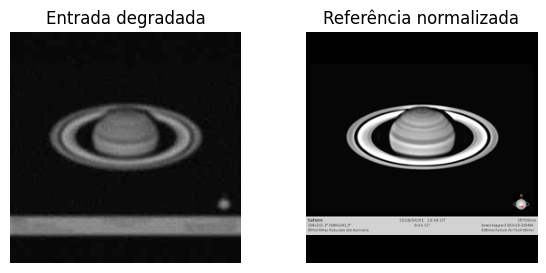

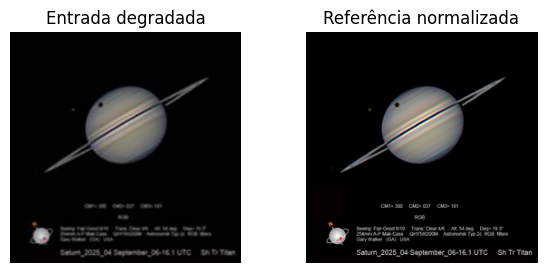

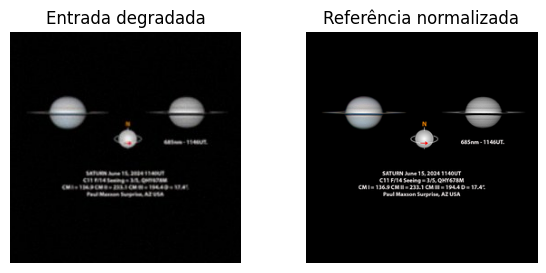

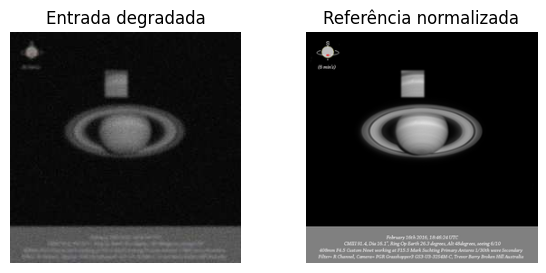

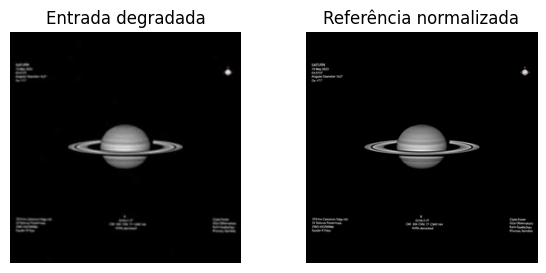

In [14]:
import matplotlib.pyplot as plt

sample_pairs = pairs_df.sample(min(5, len(pairs_df)), random_state=RANDOM_SEED)

for _, row in sample_pairs.iterrows():
    degraded = Image.open(row["degraded_path"]).convert("RGB")
    target = Image.open(row["target_path"]).convert("RGB")

    plt.figure(figsize=(7, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(degraded)
    plt.title("Entrada degradada")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(target)
    plt.title("Referência normalizada")
    plt.axis("off")

    plt.show()

## 13.1 Confirmação automática de conteúdo via Hugging Face (componente V)

O critério exige disco e anéis visíveis ao mesmo tempo, contra uma lista de rótulos negativos que cobre explicitamente os casos que motivaram esse endurecimento — imagens sem anéis claramente visíveis, recortes parciais do disco, ícones, gráficos e conteúdo sem relação com o tema. Um rótulo específico e uma terceira categoria de resultado (fila de revisão, além de confirmado e reprovado) tratam do período em que os anéis de Saturno aparecem quase de perfil, um fenômeno real do próprio planeta que um critério rígido demais rejeitaria por engano.

Esta versão corrige um problema descoberto ao comparar duas execuções sucessivas: a taxa de confirmação caiu bastante entre elas, de um jeito que não fazia sentido para um catálogo praticamente igual. A causa era a lógica de reaproveitamento — a célula só verificava se uma imagem já tinha alguma linha em `visual_validation.csv`, sem checar sob qual critério essa linha foi gerada. Uma imagem confirmada em uma versão antiga, quando o rótulo positivo ainda era só "Saturno com anéis" e o limiar de confiança era mais baixo, continuava contando como confirmada indefinidamente, mesmo que o critério atual, bem mais rigoroso, nunca tivesse sido aplicado a ela de fato. A diferença de resultado entre as duas execuções refletia quantas imagens ainda carregavam decisões antigas, não uma mudança real no conteúdo do catálogo.

`CONTENT_VALIDATION_VERSION` (seção 2) resolve isso: cada linha do arquivo passa a registrar sob qual versão do critério foi classificada, e uma imagem só conta como "já revisada" se a linha correspondente tiver a versão atual. Mudar `SATURN_LABEL`, os rótulos negativos ou qualquer limiar de confiança, e atualizar essa string junto, força a reclassificação de todo o catálogo sob a regra nova — o histórico de decisões antigas continua no arquivo, mas deixa de contar para o componente V ou para a fila de revisão. A célula também imprime a distribuição de confiança por status, para ajudar a distinguir se uma taxa de confirmação baixa reflete o conteúdo real do catálogo ou um limiar calibrado longe do que o CLIP consegue de fato distinguir neste domínio.

In [15]:
import torch
from transformers import pipeline

validation_path = DIRS["metadata"] / "visual_validation.csv"
borderline_queue_path = DIRS["metadata"] / "borderline_review_queue.csv"

VALIDATION_COLUMNS = [
    "image_id", "status", "confirmed_saturn", "classifier_label",
    "classifier_score", "margin", "method", "criteria_version", "reviewed_at_utc",
]

# PONTO DE AJUSTE: tamanho do lote enviado ao pipeline do Hugging Face.
# Diferente da versão anterior, este valor não fatia a lista manualmente --
# ele é passado como batch_size para o próprio pipeline, que gerencia o
# particionamento internamente e costuma aproveitar melhor a sobreposição
# entre pré-processamento e inferência, principalmente em GPU.
CLASSIFY_BATCH_SIZE = 16

if validation_path.exists():
    validation_df = pd.read_csv(validation_path)
    if "criteria_version" not in validation_df.columns:
        # Arquivo de uma versão anterior a este versionamento: trata todo
        # registro existente como se fosse de um critério desconhecido,
        # o que força a reclassificação de tudo sob o critério atual.
        validation_df["criteria_version"] = "desconhecido_pre_versionamento"
else:
    validation_df = pd.DataFrame(columns=VALIDATION_COLUMNS)

def get_current_criteria_view(df, current_ids):
    """Para cada image_id do catálogo atual, mantém só a linha classificada
    sob CONTENT_VALIDATION_VERSION, se existir. Uma imagem com apenas uma
    linha de um critério antigo conta como ainda não classificada sob o
    critério vigente -- é isso que impede que uma confirmação feita sob um
    padrão mais permissivo de uma versão anterior continue valendo para
    sempre depois que o critério fica mais rigoroso."""
    df = df[df["image_id"].astype(str).isin(current_ids)].copy()

    # PONTO DE AJUSTE: parsing defensivo de reviewed_at_utc.
    # errors="coerce" evita que um registro histórico com data vazia ou em
    # formato inconsistente (de uma versão anterior do notebook) quebre a
    # ordenação ou, pior, faça o sort_values tratar tudo como igual e
    # devolver um "last" que não é de fato o mais recente.
    df["_reviewed_at_parsed"] = pd.to_datetime(df["reviewed_at_utc"], errors="coerce")

    df = df[df["criteria_version"] == CONTENT_VALIDATION_VERSION]
    df = df.sort_values("_reviewed_at_parsed").drop_duplicates("image_id", keep="last")
    return df.drop(columns=["_reviewed_at_parsed"])

current_ids = set(master_df["image_id"].astype(str))
current_view = get_current_criteria_view(validation_df, current_ids)
already_classified_current = set(current_view["image_id"].astype(str))

to_classify = master_df[~master_df["image_id"].astype(str).isin(already_classified_current)].reset_index(drop=True)

print(f"{len(already_classified_current)} imagem(ns) já classificada(s) sob o critério atual ({CONTENT_VALIDATION_VERSION}).")
print(f"{len(to_classify)} imagem(ns) pendente(s) de classificação nesta execução (inclui imagens novas e imagens só classificadas sob critérios anteriores).\n")

new_validation_records = []

if len(to_classify) > 0:
    device = 0 if torch.cuda.is_available() else -1

    # PONTO DE AJUSTE: precisão em GPU.
    # torch_dtype=torch.float16 só entra quando há GPU disponível. Reduz o
    # tempo de inferência do CLIP sem alterar a lógica de status abaixo,
    # que depende de confiança e margem relativas, não de precisão absoluta.
    # Se notar instabilidade nos scores comparado à versão em float32, é
    # aqui que se volta para o tipo padrão.
    pipeline_kwargs = {"device": device}
    if device == 0:
        pipeline_kwargs["torch_dtype"] = torch.float16

    classifier = pipeline(
        "zero-shot-image-classification",
        model=CLIP_MODEL_NAME,
        **pipeline_kwargs,
    )
    candidate_labels = [SATURN_LABEL, EDGE_ON_RINGS_LABEL] + NON_SATURN_LABELS
    positive_labels = {SATURN_LABEL, EDGE_ON_RINGS_LABEL}

    for batch_start in tqdm(range(0, len(to_classify), CLASSIFY_BATCH_SIZE), desc="Classificando com CLIP"):
        batch = to_classify.iloc[batch_start: batch_start + CLASSIFY_BATCH_SIZE]

        images = []
        rows_ok = []
        for _, row in batch.iterrows():
            try:
                images.append(Image.open(row["local_path"]).convert("RGB"))
                rows_ok.append(row)
            except Exception as exc:
                new_validation_records.append({
                    "image_id": row["image_id"],
                    # PONTO DE AJUSTE: status "erro" fica fora da contagem de
                    # confirmed/borderline/rejected e da tabela de
                    # distribuição de confiança no final da célula. Isso
                    # evita que falhas de leitura de arquivo (score 0.0)
                    # puxem artificialmente para baixo a média de "rejected"
                    # e distorçam a leitura sobre se os limiares precisam
                    # de recalibração.
                    "status": "erro",
                    "confirmed_saturn": False,
                    "classifier_label": f"erro_ao_abrir: {type(exc).__name__}",
                    "classifier_score": 0.0,
                    "margin": 0.0,
                    "method": "clip_zero_shot",
                    "criteria_version": CONTENT_VALIDATION_VERSION,
                    "reviewed_at_utc": utc_now_iso(),
                })

        if not images:
            continue

        # PONTO DE AJUSTE: proteção contra falha na própria inferência.
        # A versão anterior só protegia a abertura da imagem com PIL; se o
        # classifier() falhasse aqui (arquivo truncado que abre mas não
        # decodifica por completo, pico de memória na GPU, etc.), o lote
        # inteiro era perdido e precisava ser reprocessado do zero na
        # próxima execução. Agora o lote falho é registrado como erro e a
        # execução segue para o próximo lote sem perder o que já foi salvo.
        try:
            results = classifier(images, candidate_labels=candidate_labels)
        except Exception as exc:
            for row in rows_ok:
                new_validation_records.append({
                    "image_id": row["image_id"],
                    "status": "erro",
                    "confirmed_saturn": False,
                    "classifier_label": f"erro_ao_classificar: {type(exc).__name__}",
                    "classifier_score": 0.0,
                    "margin": 0.0,
                    "method": "clip_zero_shot",
                    "criteria_version": CONTENT_VALIDATION_VERSION,
                    "reviewed_at_utc": utc_now_iso(),
                })
            continue

        if isinstance(results, dict):
            results = [results]

        for row, result in zip(rows_ok, results):
            ranked = sorted(result, key=lambda r: r["score"], reverse=True)
            top, second = ranked[0], ranked[1]
            margin = top["score"] - second["score"]

            # PONTO DE AJUSTE PRINCIPAL DO PROJETO: estes três limiares são
            # os mesmos que a v7 recalibrou, e o limiar de confirmação foi
            # recalibrado de novo nesta versão (ver seção 2,
            # SATURN_CONFIDENCE_THRESHOLD, SATURN_MARGIN_THRESHOLD,
            # BORDERLINE_CONFIDENCE_THRESHOLD). A tabela de distribuição de
            # confiança impressa no final desta célula é a referência para
            # saber se vale mexer neles de novo.
            #
            # Correção nesta versão: a condição de confirmação usava
            # top["label"] == SATURN_LABEL, o que excluía por construção
            # qualquer imagem com o rótulo de anéis quase de perfil
            # (EDGE_ON_RINGS_LABEL) da confirmação automática, não importa
            # o score ou a margem — essas imagens caíam sempre na fila de
            # revisão, mesmo com confiança e margem tão altas quanto as do
            # rótulo padrão. Como o rótulo de anéis de perfil já é tratado
            # como resultado positivo legítimo em todo o resto do notebook
            # (é o próprio motivo de existir uma terceira categoria, em vez
            # de só confirmado/reprovado), a checagem agora usa
            # `top["label"] in positive_labels` para os dois rótulos
            # positivos, aplicando exatamente o mesmo padrão de confiança e
            # margem que já era usado para o rótulo padrão.
            if (
                top["label"] in positive_labels
                and top["score"] >= SATURN_CONFIDENCE_THRESHOLD
                and margin >= SATURN_MARGIN_THRESHOLD
            ):
                status = "confirmed"
            elif top["label"] in positive_labels and top["score"] >= BORDERLINE_CONFIDENCE_THRESHOLD:
                status = "borderline"
            else:
                status = "rejected"

            new_validation_records.append({
                "image_id": row["image_id"],
                "status": status,
                "confirmed_saturn": status == "confirmed",
                "classifier_label": top["label"],
                "classifier_score": round(float(top["score"]), 4),
                "margin": round(float(margin), 4),
                "method": "clip_zero_shot",
                "criteria_version": CONTENT_VALIDATION_VERSION,
                "reviewed_at_utc": utc_now_iso(),
            })

if new_validation_records:
    validation_df = pd.concat([validation_df, pd.DataFrame(new_validation_records)], ignore_index=True)
    validation_df.to_csv(validation_path, index=False)

# Visão final: só a linha mais recente de cada imagem do catálogo atual,
# classificada sob o critério vigente.
current_view = get_current_criteria_view(validation_df, current_ids)
borderline_df = current_view[current_view["status"] == "borderline"]
borderline_df.to_csv(borderline_queue_path, index=False)

n_confirmed = int((current_view["status"] == "confirmed").sum())
n_borderline = int((current_view["status"] == "borderline").sum())
n_rejected = int((current_view["status"] == "rejected").sum())
n_erro = int((current_view["status"] == "erro").sum())
n_total_rows = len(validation_df)
n_current_rows = len(current_view)

print(f"\nClassificação salva em: {validation_path}")
print(f"Confirmadas: {n_confirmed} | Fila de revisão: {n_borderline} | Reprovadas: {n_rejected} | Erros de leitura/inferência: {n_erro} (de {n_current_rows} imagens classificadas sob o critério atual, {len(master_df)} no catálogo mestre)")
if n_total_rows > n_current_rows:
    print(f"({n_total_rows - n_current_rows} registro(s) de execuções anteriores ficam fora dessa contagem: critério antigo ou imagem que já saiu do catálogo. Continuam no arquivo para histórico.)")
if n_erro > 0:
    print(f"\nAtenção: {n_erro} imagem(ns) com falha de leitura ou de inferência, fora da contagem de rejeitadas para não distorcer a tabela de distribuição abaixo. Verifique classifier_label para o tipo de erro.")
if n_borderline > 0:
    print(f"Fila de revisão humana salva em: {borderline_queue_path}")
    print(borderline_df[["image_id", "classifier_label", "classifier_score", "margin"]].to_string(index=False))

# PONTO DE AJUSTE: esta tabela agora reflete só confirmed/borderline/rejected
# (erro está fora), o que deixa a leitura mais limpa para decidir se um
# limiar precisa mudar. Se muitas "rejected" tiverem score próximo de
# BORDERLINE_CONFIDENCE_THRESHOLD, é sinal de que vale baixar esse limiar
# em vez de aceitar a reprovação como definitiva.
score_distribution = (
    current_view[current_view["status"] != "erro"]
    .groupby("status")["classifier_score"]
    .describe()[["count", "mean", "min", "25%", "50%", "75%", "max"]]
)
print("\nDistribuição de confiança por status:")
print(score_distribution.to_string())

84 imagem(ns) já classificada(s) sob o critério atual (v4_edge_on_confirmavel_limiar_038).
916 imagem(ns) pendente(s) de classificação nesta execução (inclui imagens novas e imagens só classificadas sob critérios anteriores).



config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

Classificando com CLIP:   0%|          | 0/58 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Classificação salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/visual_validation.csv
Confirmadas: 295 | Fila de revisão: 114 | Reprovadas: 591 | Erros de leitura/inferência: 0 (de 1000 imagens classificadas sob o critério atual, 1000 no catálogo mestre)
(916 registro(s) de execuções anteriores ficam fora dessa contagem: critério antigo ou imagem que já saiu do catálogo. Continuam no arquivo para histórico.)
Fila de revisão humana salva em: /content/drive/MyDrive/dataset_saturno_v1/metadata/borderline_review_queue.csv
        image_id                                                                                          classifier_label  classifier_score  margin
550a4a3cbc2330f2 a photo of the planet Saturn with its rings seen nearly edge-on, appearing as a thin line across the disk            0.3552  0.0742
0ced95c23f9d5ad5 a photo of the planet Saturn with its rings seen nearly edge-on, appearing as a thin line across the disk            0.3752  0.1252
eae4093fd4eafae2 

## 13.2 Manifesto de aprovação para a Fase 2 (novo nesta versão)

A execução anterior mostrou a Fase 2 rodando sua própria classificação CLIP do zero, com rótulos e limiares ligeiramente diferentes dos usados aqui, e sem a exceção para anéis quase de perfil. Isso duplicava o custo de inferência e permitia que os dois notebooks divergissem sobre quais imagens são Saturno válido. A partir desta versão, esta etapa exporta `approved_for_training.csv`, com uma linha por imagem do catálogo mestre classificada sob o `CONTENT_VALIDATION_VERSION` vigente, contendo `image_id`, `status` (confirmed, borderline ou rejected) e a própria versão do critério. A Fase 2 lê este arquivo diretamente em vez de reclassificar as imagens; a classificação própria da Fase 2 continua existindo no notebook de treino apenas como alternativa, usada somente se este arquivo não for encontrado.

In [16]:
approved_for_training_path = DIRS["metadata"] / "approved_for_training.csv"

approved_for_training_df = current_view[["image_id", "status", "criteria_version"]].copy()
approved_for_training_df = approved_for_training_df.rename(columns={"criteria_version": "content_validation_version"})
approved_for_training_df.to_csv(approved_for_training_path, index=False)

print(f"Manifesto de aprovação para a Fase 2 salvo em: {approved_for_training_path}")
print(approved_for_training_df["status"].value_counts())


Manifesto de aprovação para a Fase 2 salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/approved_for_training.csv
status
rejected      591
confirmed     295
borderline    114
Name: count, dtype: int64


## 13.3 Revisão Manual de imagens

Este bloco segura o processamento até que seja feita uma analise das imagens paradas em revisão. `borderline_review_queue.csv, images_metadata.csv, manual_review_decisions.csv`

In [17]:
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

# -----------------------------------------------------------------------------
# 1. Carregar a fila de revisão e localizar o caminho de cada imagem
# -----------------------------------------------------------------------------
metadata_dir = DIRS["metadata"]  # reaproveita o DIRS já definido no notebook

borderline_path = metadata_dir / "borderline_review_queue.csv"
master_path = metadata_dir / "images_metadata.csv"
decisions_path = metadata_dir / "manual_review_decisions.csv"

borderline_df = pd.read_csv(borderline_path)
# Fixed: Load all columns of master_df, as 'license_note' is needed later.
master_df = pd.read_csv(master_path)

queue_df = borderline_df.merge(master_df, on="image_id", how="left")

if queue_df["local_path"].isna().any():
    n_missing = int(queue_df["local_path"].isna().sum())
    print(f"Aviso: {n_missing} imagem(ns) da fila não encontrada(s) no catálogo mestre "
          f"(local_path ausente). Elas serão puladas na revisão.")
    queue_df = queue_df.dropna(subset=["local_path"]).reset_index(drop=True)

# Carrega decisões já salvas em execuções anteriores, para retomar de onde parou
if decisions_path.exists():
    decisions_df = pd.read_csv(decisions_path)
    already_reviewed = set(decisions_df["image_id"].astype(str))
else:
    decisions_df = pd.DataFrame(columns=["image_id", "decision", "reviewed_at_utc"])
    already_reviewed = set()

pending_df = queue_df[~queue_df["image_id"].astype(str).isin(already_reviewed)].reset_index(drop=True)

print(f"Fila total: {len(queue_df)} | Já revisadas: {len(already_reviewed)} | Pendentes: {len(pending_df)}")

# -----------------------------------------------------------------------------
# 2. Interface de revisão, uma imagem por vez
# -----------------------------------------------------------------------------
current_index = {"i": 0}

image_widget = widgets.Image(format="png", width=500)
info_label = widgets.HTML()
progress_label = widgets.HTML()
approve_btn = widgets.Button(description="Aprovar", button_style="success", icon="check")
reject_btn = widgets.Button(description="Reprovar", button_style="danger", icon="times")
skip_btn = widgets.Button(description="Pular por agora", button_style="")
output_area = widgets.Output()

def save_decision(image_id, decision):
    global decisions_df
    new_row = pd.DataFrame([{
        "image_id": image_id,
        "decision": decision,
        "reviewed_at_utc": datetime.now(timezone.utc).isoformat(),
    }])
    decisions_df = pd.concat([decisions_df, new_row], ignore_index=True)
    decisions_df.to_csv(decisions_path, index=False)

def load_current():
    with output_area:
        clear_output(wait=True)
    i = current_index["i"]
    if i >= len(pending_df):
        image_widget.value = b""
        info_label.value = "<b>Revisão concluída — não há mais imagens pendentes na fila.</b>"
        progress_label.value = ""
        approve_btn.disabled = True
        reject_btn.disabled = True
        skip_btn.disabled = True
        return

    row = pending_df.iloc[i]
    img_path = Path(row["local_path"])

    try:
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            img.thumbnail((500, 500))
            buf = io.BytesIO()
            img.save(buf, format="PNG")
            image_widget.value = buf.getvalue()
    except Exception as exc:
        image_widget.value = b""
        info_label.value = f"<b>Erro ao abrir imagem:</b> {exc}"

    info_label.value = (
        f"<b>image_id:</b> {row['image_id']} &nbsp; "
        f"<b>fonte:</b> {row['source']} &nbsp; "
        f"<b>rótulo do classificador:</b> {row['classifier_label']}<br>"
        f"<b>score:</b> {row['classifier_score']:.3f} &nbsp; "
        f"<b>margem:</b> {row['margin']:.3f}"
    )
    progress_label.value = f"Imagem {i + 1} de {len(pending_df)} pendentes"

def go_next():
    current_index["i"] += 1
    load_current()

def on_approve(b):
    row = pending_df.iloc[current_index["i"]]
    save_decision(row["image_id"], "approved")
    go_next()

def on_reject(b):
    row = pending_df.iloc[current_index["i"]]
    save_decision(row["image_id"], "rejected")
    go_next()

def on_skip(b):
    go_next()

approve_btn.on_click(on_approve)
reject_btn.on_click(on_reject)
skip_btn.on_click(on_skip)

load_current()

display(widgets.VBox([
    progress_label,
    image_widget,
    info_label,
    widgets.HBox([approve_btn, reject_btn, skip_btn]),
    output_area,
]))

# -----------------------------------------------------------------------------
# 3. Depois de revisar tudo (ou parar quando quiser), rode esta célula à parte
#    para gerar o manifesto final incorporando as decisões manuais.
# -----------------------------------------------------------------------------
def gerar_manifesto_final():
    """Combina approved_for_training.csv com as decisões manuais desta revisão.

    Regra (revisada): 'confirmed' continua aprovado com qualidade 'high'.
    'borderline' com decisão manual 'approved' vira 'confirmed_by_manual_review',
    qualidade 'high'. 'borderline' com decisão manual 'rejected' vira 'rejected'.

    Mudança nesta versão: 'borderline' SEM nenhuma decisão registrada deixa de
    ser tratado como reprovado por omissão. Por decisão do projeto, esse caso
    agora vira 'confirmed_pending_review' -- aprovado para treino, mas marcado
    com qualidade 'low' na coluna quality_tier, para que a Fase 2 e o artigo
    consigam reportar separadamente o desempenho sobre conteúdo confirmado com
    alta confiança e sobre conteúdo aceito com critério mais permissivo. Uma
    imagem só sai do treino quando há uma decisão manual explícita de
    reprovação -- "ainda não revisada" deixou de equivaler a "reprovada".
    """
    approved_path = metadata_dir / "approved_for_training.csv"
    approved_df = pd.read_csv(approved_path)
    decisions = pd.read_csv(decisions_path) if decisions_path.exists() else pd.DataFrame(
        columns=["image_id", "decision"]
    )
    decisions_map = dict(zip(decisions["image_id"].astype(str), decisions["decision"]))

    def resolve(row):
        if row["status"] == "confirmed":
            return "confirmed", "high"
        if row["status"] == "borderline":
            d = decisions_map.get(str(row["image_id"]))
            if d == "approved":
                return "confirmed_by_manual_review", "high"
            if d == "rejected":
                return "rejected", None
            return "confirmed_pending_review", "low"
        return "rejected", None

    resolved = approved_df.apply(resolve, axis=1, result_type="expand")
    approved_df["final_status"] = resolved[0]
    approved_df["quality_tier"] = resolved[1]

    final_path = metadata_dir / "approved_for_training_final.csv"
    approved_df.to_csv(final_path, index=False)
    print(f"Manifesto final salvo em: {final_path}")
    print(approved_df["final_status"].value_counts())
    print("\nQualidade entre as aprovadas (high = confirmada com alta confiança "
          "ou revisão manual explícita; low = aprovada por default da fila "
          "borderline sem revisão manual concluída):")
    print(approved_df.loc[approved_df["final_status"] != "rejected", "quality_tier"].value_counts())
    return approved_df

# Para gerar o manifesto final depois de revisar, rode:
# gerar_manifesto_final()

Fila total: 114 | Já revisadas: 0 | Pendentes: 114


## 13.4 Gerar manifesto final incorporando a revisão manual

A célula 13.3 salva cada decisão (aprovar/reprovar) em `manual_review_decisions.csv` assim que o botão é clicado, mas isso por si só não altera o que a Fase 2 vai efetivamente usar para treino. Esta célula chama `gerar_manifesto_final()`, definida na seção anterior, para cruzar `approved_for_training.csv` (gerado na seção 13.2) com as decisões manuais e produzir `approved_for_training_final.csv`, com duas colunas novas: `final_status`, que resolve cada imagem em `confirmed`, `confirmed_by_manual_review`, `confirmed_pending_review` ou `rejected`; e `quality_tier`, que marca como `high` tudo que teve confirmação automática de alta confiança ou revisão manual explícita, e como `low` o que veio da fila borderline sem revisão concluída.

**Mudança de política nesta versão:** borderline sem decisão manual registrada deixou de ser tratado como reprovado por omissão. Antes, qualquer imagem na fila que não tivesse sido explicitamente aprovada ou reprovada virava `rejected` no manifesto final -- o que, na prática, esvaziava o efeito de a Fase 2 ter passado a aceitar "tudo que não é rejected", já que o próprio manifesto da Fase 1 pré-resolvia esses casos como reprovados antes de a Fase 2 olhar para eles. Agora esses casos viram `confirmed_pending_review`, entram no treino, e ficam marcados com `quality_tier = "low"` para que a Fase 2 e o artigo consigam reportar separadamente o desempenho sobre conteúdo de alta confiança e sobre conteúdo aprovado com critério mais permissivo. Isso é uma decisão deliberada de priorizar volume de dados sobre um filtro mais rígido, e deve ficar registrada como tal na seção de metodologia do artigo.

Rode esta célula depois de concluir (ou pausar) a revisão na seção 13.3. Pode ser executada de novo a qualquer momento para atualizar o manifesto final com decisões adicionais, sem precisar refazer a revisão já feita -- inclusive para promover imagens de `confirmed_pending_review` a `confirmed_by_manual_review` conforme a fila for sendo revisada.

In [18]:
manifesto_final_df = gerar_manifesto_final()

Manifesto final salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/approved_for_training_final.csv
final_status
rejected                    591
confirmed                   295
confirmed_pending_review    114
Name: count, dtype: int64

Qualidade entre as aprovadas (high = confirmada com alta confiança ou revisão manual explícita; low = aprovada por default da fila borderline sem revisão manual concluída):
quality_tier
high    295
low     114
Name: count, dtype: int64


## 14. Relatório final da base v1

A última etapa consolida os números de toda a execução em um dicionário e salva `dataset_summary.json`: quantas imagens reais válidas, quantas normalizadas, quantos pares sintéticos, a distribuição por split e por fonte, e o score de maturidade Q.

A regra de cálculo de Q mudou nesta versão. A validação individual de licença (componente L) deixou de ser exigida para o score avançar — o esqueleto de `licenses.csv` continua sendo gerado a cada execução, e a revisão de licença continua sendo pré-requisito para publicar o dataset ou usar as imagens fora do ambiente de pesquisa, mas não bloqueia mais a leitura de "dataset pronto para a Fase 2" feita a partir de Q. O peso que antes ia para L foi redistribuído entre metadados (M), deduplicação (D), split sem vazamento (S) e confirmação de conteúdo (V), que são os quatro componentes efetivamente ligados à qualidade técnica do dataset para treinamento. O componente V agora vem da classificação automática feita na seção 13.1, em vez de ficar fixo em zero à espera de revisão humana.

In [19]:
REQUIRED_METADATA_FIELDS = [
    "source", "original_url", "sha1_file", "license_note",
    "observer", "date_utc", "local_path",
]

def compute_maturity_score(master_df, split_df, validation_df):
    # L - licença: proporção de imagens cuja license_note já foi revisada
    # manualmente. Calculado sempre, para fins de acompanhamento, mas só
    # entra no peso de Q se REQUIRE_LICENSE_FOR_MATURITY for True (seção 2).
    default_license_text = "verificar licença/autoria antes de uso público"
    if len(master_df) > 0:
        reviewed = (master_df["license_note"].astype(str) != default_license_text).sum()
        L = reviewed / len(master_df)
    else:
        L = 0.0

    # M - metadados: proporção média de campos mínimos preenchidos.
    if len(master_df) > 0:
        filled_ratios = []
        for _, row in master_df.iterrows():
            filled = sum(1 for f in REQUIRED_METADATA_FIELDS if str(row.get(f, "")).strip() not in ("", "nan", "None"))
            filled_ratios.append(filled / len(REQUIRED_METADATA_FIELDS))
        M = sum(filled_ratios) / len(filled_ratios)
    else:
        M = 0.0

    # D - deduplicação: 1.0 porque o catálogo mestre já é deduplicado por
    # sha1_file nesta etapa do pipeline.
    D = 1.0

    # S - split sem vazamento: verifica se algum observador aparece em
    # mais de um split.
    if len(split_df) > 0 and "observer" in split_df.columns:
        obs_splits = split_df[split_df["observer"].astype(str).str.strip() != ""]
        if len(obs_splits) > 0:
            leak = obs_splits.groupby("observer")["split"].nunique()
            S = 1.0 if (leak <= 1).all() else 0.0
        else:
            S = 1.0
    else:
        S = 0.0

    # V - confirmação de conteúdo: calculada a partir de
    # visual_validation.csv, preenchido na seção 13.1 por um classificador
    # CLIP zero-shot (Hugging Face) com três resultados possíveis:
    # confirmada, fila de revisão (borderline_review_queue.csv) e
    # reprovada. Só as confirmadas contam a favor de V; imagens na fila
    # de revisão não contam a favor nem bloqueiam o pipeline, mas também
    # não entram no treinamento até serem promovidas manualmente a
    # confirmadas. Imagens ainda não classificadas também contam contra V
    # até que a seção 13.1 seja executada sobre elas.
    if len(master_df) > 0 and len(validation_df) > 0:
        master_ids = set(master_df["image_id"].astype(str))
        classified_ids = set(validation_df["image_id"].astype(str)) & master_ids
        confirmed_ids = set(
            validation_df.loc[validation_df["confirmed_saturn"] == True, "image_id"].astype(str)
        ) & master_ids
        V = len(confirmed_ids) / len(master_df)
        review_coverage = len(classified_ids) / len(master_df)
    else:
        V = 0.0
        review_coverage = 0.0

    # Nesta versão, a validação de licença deixou de gatilhar o score de
    # maturidade por padrão (REQUIRE_LICENSE_FOR_MATURITY = False). O peso
    # que antes ia para L é redistribuído entre metadados, deduplicação,
    # split e validação visual, que são os componentes relevantes para
    # decidir se o dataset já serve para a Fase 2 (treinamento).
    if REQUIRE_LICENSE_FOR_MATURITY:
        weights = {"L": 0.25, "M": 0.25, "D": 0.20, "S": 0.15, "V": 0.15}
    else:
        weights = {"L": 0.0, "M": 0.35, "D": 0.25, "S": 0.20, "V": 0.20}

    Q = weights["L"] * L + weights["M"] * M + weights["D"] * D + weights["S"] * S + weights["V"] * V

    return {
        "L_licenca": round(L, 3),
        "M_metadados": round(M, 3),
        "D_deduplicacao": round(D, 3),
        "S_split_sem_vazamento": round(S, 3),
        "V_validacao_visual": round(V, 3),
        "V_cobertura_revisao": round(review_coverage, 3),
        "pesos_usados": weights,
        "licenca_exigida_para_Q": REQUIRE_LICENSE_FOR_MATURITY,
        "Q_score_maturidade": round(Q, 3),
    }

licenses_path = DIRS["metadata"] / "licenses.csv"
if len(master_df) > 0:
    licenses_df = pd.DataFrame({
        "image_id": master_df["image_id"],
        "source": master_df["source"],
        "author": master_df.get("observer", ""),
        "license_type": "",
        "permission_status": "pending_review",
        "restriction": "",
        "review_date": "",
    })
    licenses_df.to_csv(licenses_path, index=False)
    print(f"Esqueleto de licenças salvo em: {licenses_path}")
    print("Revisão de licença segue recomendada antes de qualquer publicação, mas não bloqueia mais o score Q.")

validation_path_for_score = DIRS["metadata"] / "visual_validation.csv"
if validation_path_for_score.exists():
    validation_df_for_score = pd.read_csv(validation_path_for_score)
    if "criteria_version" not in validation_df_for_score.columns:
        validation_df_for_score["criteria_version"] = "desconhecido_pre_versionamento"
    # Mesma lógica da seção 13.1: só conta para o score a classificação
    # feita sob o critério vigente (CONTENT_VALIDATION_VERSION). Sem isso,
    # uma imagem confirmada sob um critério antigo mais permissivo
    # continuaria contando a favor de V mesmo depois do critério ter
    # ficado mais rigoroso, o que já aconteceu de fato entre duas
    # execuções deste notebook.
    current_ids_for_score = set(master_df["image_id"].astype(str))
    validation_df_for_score = validation_df_for_score[
        validation_df_for_score["image_id"].astype(str).isin(current_ids_for_score)
        & (validation_df_for_score["criteria_version"] == CONTENT_VALIDATION_VERSION)
    ].sort_values("reviewed_at_utc").drop_duplicates("image_id", keep="last")
else:
    validation_df_for_score = pd.DataFrame(columns=["image_id", "confirmed_saturn", "reviewed_at_utc"])

maturity = compute_maturity_score(master_df, split_df, validation_df_for_score)

summary = {
    "dataset_name": DATASET_NAME,
    "dataset_root": str(DATASET_ROOT),
    "created_at_utc": utc_now_iso(),
    "initial_image_count_requested": INITIAL_IMAGE_COUNT,
    "real_images_valid": int(len(master_df)),
    "normalized_images": int((norm_df["status"] == "ok").sum()),
    "synthetic_pairs": int(len(pairs_df)),
    "real_split_counts": split_df["split"].value_counts().to_dict() if len(split_df) else {},
    "synthetic_split_counts": pairs_df["split"].value_counts().to_dict() if len(pairs_df) else {},
    "sources": master_df["source"].value_counts().to_dict() if len(master_df) else {},
    "maturity_score": maturity,
    "important_note": (
        "Toda imagem processada por IA deve ser marcada como processada. "
        "As imagens brutas e os metadados de origem devem ser preservados. "
        "A validação de licença (componente L) segue registrada em "
        "licenses.csv e continua obrigatória antes de qualquer publicação "
        "ou uso fora do ambiente de pesquisa, mesmo não entrando mais no "
        "cálculo padrão do score Q."
    )
}

summary_path = DIRS["metadata"] / "dataset_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print(json.dumps(summary, indent=2, ensure_ascii=False))
print(f"Resumo salvo em: {summary_path}")

Esqueleto de licenças salvo em: /content/drive/MyDrive/dataset_saturno_v1/metadata/licenses.csv
Revisão de licença segue recomendada antes de qualquer publicação, mas não bloqueia mais o score Q.
{
  "dataset_name": "dataset_saturno_v1",
  "dataset_root": "/content/drive/MyDrive/dataset_saturno_v1",
  "created_at_utc": "2026-07-13T21:43:53.650645+00:00",
  "initial_image_count_requested": 1000,
  "real_images_valid": 1000,
  "normalized_images": 1000,
  "synthetic_pairs": 1200,
  "real_split_counts": {
    "train": 700,
    "test": 151,
    "val": 149
  },
  "synthetic_split_counts": {
    "train": 840,
    "val": 180,
    "test": 180
  },
  "sources": {
    "pvol": 917,
    "baa": 73,
    "alpo_japan": 10
  },
  "maturity_score": {
    "L_licenca": 0.0,
    "M_metadados": 0.976,
    "D_deduplicacao": 1.0,
    "S_split_sem_vazamento": 1.0,
    "V_validacao_visual": 0.295,
    "V_cobertura_revisao": 1.0,
    "pesos_usados": {
      "L": 0.0,
      "M": 0.35,
      "D": 0.25,
      "S": 